In [1]:
import demes
import msprime
import tszip
import tskit
import numpy as np
import pandas as pd
import yaml
import demesdraw
import sys
import matplotlib.pyplot as plt
sys.path.append("../")
from arg_hmm.utils import ARG_utils, Performance_utils, Figure_utils
from arg_hmm.arg_hmm import GhostProductHmm
import yaml
from pathlib import Path
import matplotlib
from mycolorpy import colorlist as mcp
import scipy.stats as stats
from KDEpy import FFTKDE
from scipy.interpolate import interp1d
import seaborn as sns
from matplotlib.ticker import ScalarFormatter
from brokenaxes import brokenaxes
from matplotlib.gridspec import GridSpec
from scipy.stats import ks_2samp
from scipy.stats import pearsonr, spearmanr

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Plot Emission & Transition

In [38]:
data = np.load("../results/hmm_results/inference_comparison/split_constant/m2_ori/Ghost_HMM/n100_seed1_15000_0.02_ppsind0.npz")
t1s = data["at1s"]
t2s = data["at2s"]
ncoal = data["ancoal"]
treespan = data["a_tree_span"]
params = pd.DataFrame(data["a_param"], columns=["iters", "logliks", "p", "q", "pi0", "a1", "b1", "a2", "b2"])
params = params[params["iters"] > 0]
idx = 0
truth = Performance_utils().read_truth_bed("../results/hmm_results/inference_comparison/split_constant/m2_ori/simulations/n100_seed1_withARC.indiv.bed", 200)
didx = []
for x in truth[idx]:
    [x1,x2] = x
    for i in range(treespan.shape[0]):
        [y1,y2] = treespan[i]
        if (max(x1,y1) < min(x2,y2)):
            didx.append(i)
n_idx = [i for i in range(treespan.shape[0]) if i not in didx]

/global/scratch/users/zhangyulin9806/tmp/ipykernel_2059856/2881772762.py:17: RuntimeWarning: divide by zero encountered in divide
  dff_vec = ncoal / (t2s - t1s)


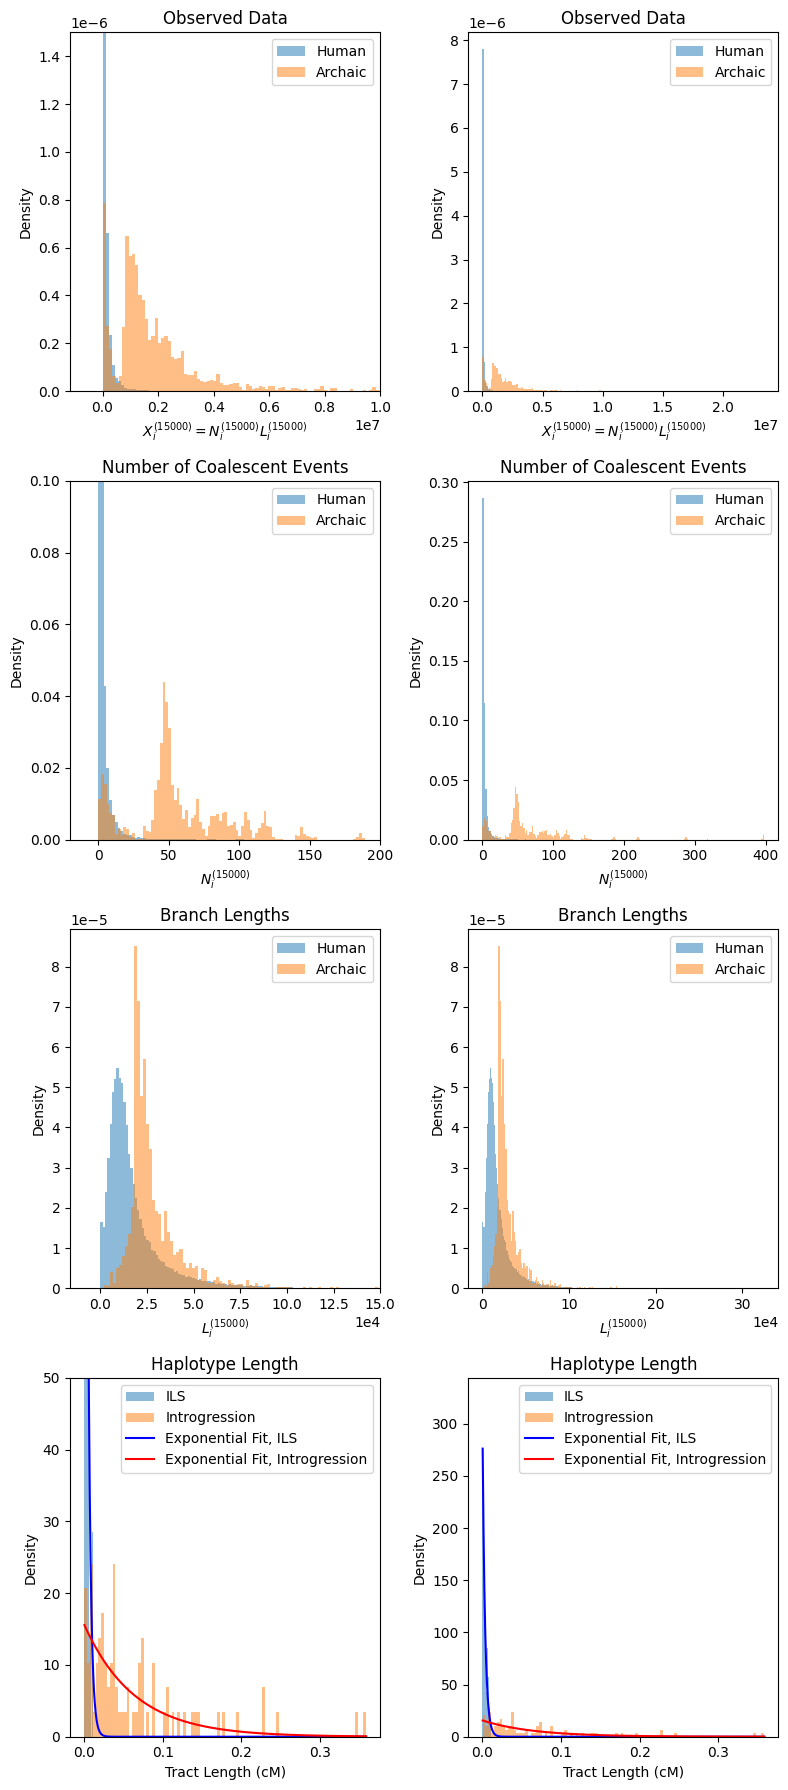

In [45]:
dff_vec = ncoal
fig, ax = plt.subplots(4,2,figsize=(8,18))
ax[0][0].hist(dff_vec[n_idx], bins=200, label='Human', alpha = 0.5, density=True)
ax[0][0].hist(dff_vec[didx], bins=200, label='Archaic', alpha = 0.5, density=True)
ax[0][0].set_ylim(ymax = 1.5e-6)
ax[0][0].set_xlim(xmax = 1e7)
ax[0][0].set_xlabel(r"$X_{i}^{(15000)} = N_{i}^{(15000)}L_{i}^{(15000)}$")
ax[0][0].set_ylabel('Density')
ax[0][0].set_title('Observed Data')
ax[0][0].legend()
ax[0][1].hist(dff_vec[n_idx], bins=200, label='Human', alpha = 0.5, density=True)
ax[0][1].hist(dff_vec[didx], bins=200, label='Archaic', alpha = 0.5, density=True)
ax[0][1].set_xlabel(r"$X_{i}^{(15000)} = N_{i}^{(15000)}L_{i}^{(15000)}$")
ax[0][1].set_ylabel('Density')
ax[0][1].set_title('Observed Data')
ax[0][1].legend()
dff_vec = ncoal / (t2s - t1s)
dff_vec[dff_vec == np.inf] = 0
ax[1][0].hist(dff_vec[n_idx], bins=200, label='Human', alpha = 0.5, density=True)
ax[1][0].hist(dff_vec[didx], bins=200, label='Archaic', alpha = 0.5, density=True)
ax[1][0].set_ylim(ymax = 0.1)
ax[1][0].set_xlim(xmax = 200)
ax[1][0].set_xlabel(r"$N_{i}^{(15000)}$")
ax[1][0].set_ylabel('Density')
ax[1][0].set_title('Number of Coalescent Events')
ax[1][0].legend()
ax[1][1].hist(dff_vec[n_idx], bins=200, label='Human', alpha = 0.5, density=True)
ax[1][1].hist(dff_vec[didx], bins=200, label='Archaic', alpha = 0.5, density=True)
ax[1][1].set_xlabel(r"$N_{i}^{(15000)}$")
ax[1][1].set_ylabel('Density')
ax[1][1].set_title('Number of Coalescent Events')
ax[1][1].legend()
dff_vec = t2s - t1s
dff_vec[dff_vec == np.inf] = 0
ax[2][0].hist(dff_vec[n_idx], bins=200, label='Human', alpha = 0.5, density=True)
ax[2][0].hist(dff_vec[didx], bins=200, label='Archaic', alpha = 0.5, density=True)
ax[2][0].set_xlim(xmax = 150000)
formatter = ScalarFormatter()
formatter.set_powerlimits((4, 4))
ax[2][0].xaxis.set_major_formatter(formatter)
ax[2][0].set_xlabel(r"$L_{i}^{(15000)}$")
ax[2][0].set_ylabel('Density')
ax[2][0].set_title('Branch Lengths')
ax[2][0].legend()
ax[2][1].hist(dff_vec[n_idx], bins=200, label='Human', alpha = 0.5, density=True)
ax[2][1].hist(dff_vec[didx], bins=200, label='Archaic', alpha = 0.5, density=True)
formatter = ScalarFormatter()
formatter.set_powerlimits((4, 4))
ax[2][1].xaxis.set_major_formatter(formatter)
ax[2][1].set_xlabel(r"$L_{i}^{(15000)}$")
ax[2][1].set_ylabel('Density')
ax[2][1].set_title('Branch Lengths')
ax[2][1].legend()
moc_states = np.zeros((2, treespan.shape[0]))
for i in n_idx:
    if t1s[i] < 2000 and t2s[i] > 20000:
        moc_states[0, i] = 1
for i in didx:
    moc_states[1, i] = 1
leng, _ = Performance_utils().filter_hmm_output(arc_cutoff=0.9,
    pp_cutoff=0.9,
    l_cutoff=0,
    popmerge=False,
    maxlen=None,
    combined_pp=moc_states,
    treespan=treespan,
    )
ils_length = [x[1]-x[0] for x in leng[0]]
intro_length = [x[1]-x[0] for x in leng[1]]
# fit the distribution to the data
params_ils = stats.expon.fit(ils_length)
params_intro = stats.expon.fit(intro_length)

x = np.linspace(0, max(np.max(ils_length), np.max(intro_length)), 1000)
ax[3][0].hist(ils_length, bins=100, label='ILS', alpha = 0.5, density=True)
ax[3][0].hist(intro_length, bins=100, label='Introgression', alpha = 0.5, density=True)
# plot the PDF of the fitted distribution
y_ils = stats.expon.pdf(x, *params_ils)
y_intro = stats.expon.pdf(x, *params_intro)
ax[3][0].plot(x[1:], y_ils[1:], label='Exponential Fit, ILS', color='blue')
ax[3][0].plot(x[1:], y_intro[1:], label='Exponential Fit, Introgression', color='red')
ax[3][0].set_xlabel('Tract Length (cM)')
ax[3][0].set_ylabel('Density')
ax[3][0].set_title('Haplotype Length')
ax[3][0].set_ylim(ymax = 50)
ax[3][0].legend()
ax[3][1].hist(ils_length, bins=100, label='ILS', alpha = 0.5, density=True)
ax[3][1].hist(intro_length, bins=100, label='Introgression', alpha = 0.5, density=True)
ax[3][1].plot(x[1:], y_ils[1:], label='Exponential Fit, ILS', color='blue')
ax[3][1].plot(x[1:], y_intro[1:], label='Exponential Fit, Introgression', color='red')
ax[3][1].set_xlabel('Tract Length (cM)')
ax[3][1].set_ylabel('Density')
ax[3][1].set_title('Haplotype Length')
ax[3][1].legend()
plt.tight_layout()

/global/scratch/users/zhangyulin9806/tmp/ipykernel_2059856/2049137189.py:11: RuntimeWarning: divide by zero encountered in divide
  dff_vec = ncoal / (t2s - t1s)


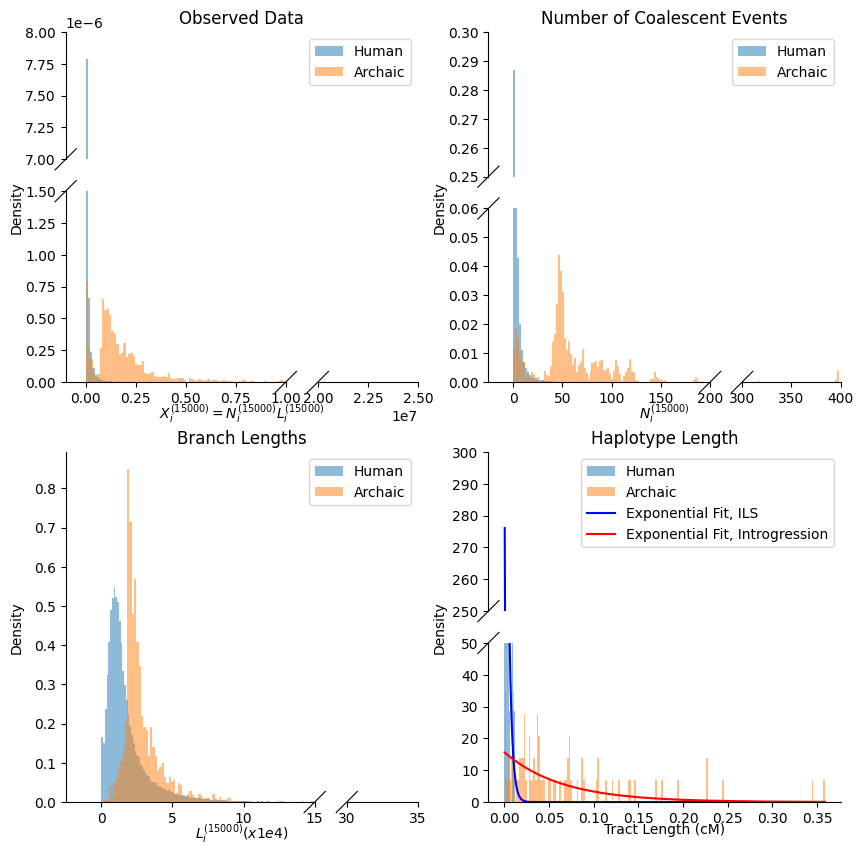

In [76]:
dff_vec = ncoal
fig = plt.figure(figsize=(10, 10))
sps1, sps2, sps3, sps4 = GridSpec(2,2)
bax = brokenaxes(xlims=((-1e6, 1e7), (2e7, 2.5e7)), ylims = ((0, 1.5e-6), (7e-6, 8e-6)), subplot_spec=sps1)
bax.hist(dff_vec[n_idx], bins=200, label='Human', alpha = 0.5, density=True)
bax.hist(dff_vec[didx], bins=200, label='Archaic', alpha = 0.5, density=True)
bax.set_xlabel(r"$X_{i}^{(15000)} = N_{i}^{(15000)}L_{i}^{(15000)}$")
bax.set_ylabel('Density')
bax.set_title('Observed Data')
bax.legend()
dff_vec = ncoal / (t2s - t1s)
dff_vec[dff_vec == np.inf] = 0
bax = brokenaxes(xlims=((-25, 200), (300, 400)), ylims = ((0, 0.06), (0.25, 0.3)), subplot_spec=sps2)
bax.hist(dff_vec[n_idx], bins=200, label='Human', alpha = 0.5, density=True)
bax.hist(dff_vec[didx], bins=200, label='Archaic', alpha = 0.5, density=True)
bax.set_xlabel(r"$N_{i}^{(15000)}$")
bax.set_ylabel('Density')
bax.set_title('Number of Coalescent Events')
bax.legend()
dff_vec = (t2s - t1s) / 1e4
dff_vec[dff_vec == np.inf] = 0
bax = brokenaxes(xlims=((-2.5, 15), (30, 35)), subplot_spec=sps3)
bax.hist(dff_vec[n_idx], bins=200, label='Human', alpha = 0.5, density=True)
bax.hist(dff_vec[didx], bins=200, label='Archaic', alpha = 0.5, density=True)
bax.set_xlabel(r"$L_{i}^{(15000)} (x 1e4)$")
bax.set_ylabel('Density')
bax.set_title('Branch Lengths')
bax.legend()
moc_states = np.zeros((2, treespan.shape[0]))
for i in n_idx:
    if t1s[i] < 2000 and t2s[i] > 20000:
        moc_states[0, i] = 1
for i in didx:
    moc_states[1, i] = 1
leng, _ = Performance_utils().filter_hmm_output(arc_cutoff=0.9,
    pp_cutoff=0.9,
    l_cutoff=0,
    popmerge=False,
    maxlen=None,
    combined_pp=moc_states,
    treespan=treespan,
    )
ils_length = [x[1]-x[0] for x in leng[0]]
intro_length = [x[1]-x[0] for x in leng[1]]
# fit the distribution to the data
params_ils = stats.expon.fit(ils_length)
params_intro = stats.expon.fit(intro_length)
x = np.linspace(0, max(np.max(ils_length), np.max(intro_length)), 1000)
# # plot the PDF of the fitted distribution
y_ils = stats.expon.pdf(x, *params_ils)
y_intro = stats.expon.pdf(x, *params_intro)
bax = brokenaxes(ylims = ((0, 50), (250, 300)), subplot_spec=sps4)
bax.hist(ils_length, bins=200, label='Human', alpha = 0.5, density=True)
bax.hist(intro_length, bins=200, label='Archaic', alpha = 0.5, density=True)
bax.plot(x[1:], y_ils[1:], label='Exponential Fit, ILS', color='blue')
bax.plot(x[1:], y_intro[1:], label='Exponential Fit, Introgression', color='red')
bax.set_xlabel(r"Tract Length (cM)")
bax.set_ylabel('Density')
bax.set_title('Haplotype Length')
bax.legend()
# fig.tight_layout()
plt.savefig("../images/figS1_1.pdf", bbox_inches='tight')

# Plot performance comparison accross methods

/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:857: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:857: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:910: RuntimeWarning: Mean of empty slice
  out.append(np.nanmean(pres))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:857: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:910: RuntimeWarning: Mean of empty slice
  out.append(np.nanmean(pres))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:857: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/user

(0.0, 1.0)

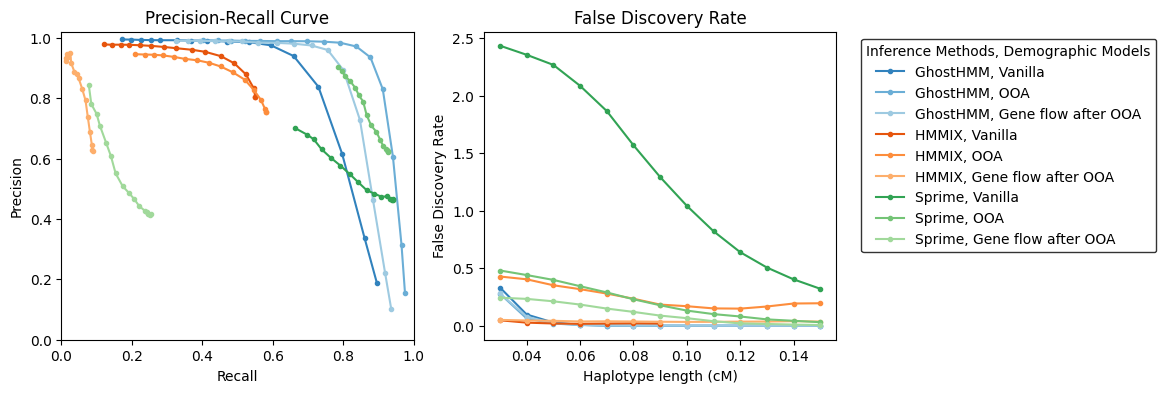

In [21]:
conf = yaml.safe_load(Path('../config/analysis.config.yaml').read_text())
seeds = conf['inference_comparison']['seeds']
n = conf['inference_comparison']['n']
pp_cutoff = conf['pp_cutoff']
l_cutoff = conf['l_cutoff']
inference = conf['inference_comparison']['models']['split_constant']['inference'][:-1]
intro = conf['inference_comparison']['models']['split_constant']['intro'][0]
t = conf['inference_comparison']['models']['split_constant']['t'][0]

versions = ['m2_ori', 'm2_ori', 'm2_ori']#, 'intro_mha'
models = ['split_constant', 'ooa_neanderthal5r19_simp', 'ooa_neanderthal5r19_comp']#, 'ooa_neanderthal5r19_simp']
pps_label = ['GhostHMM, Vanilla', 'GhostHMM, OOA', 'GhostHMM, Gene flow after OOA'] #, 'GhostHMM, Introgression before OOA'
pps_label = pps_label + ['HMMIX, Vanilla', 'HMMIX, OOA', 'HMMIX, Gene flow after OOA'] #, 'HMMIX, Introgression before OOA'
pps_label = pps_label + ['Sprime, Vanilla', 'Sprime, OOA', 'Sprime, Gene flow after OOA'] #, 'Sprime, Introgression before OOA'
#pps_label = pps_label + ['IBDmix, OOA', 'IBDmix, OOA with intro to MHA', 'IBDmix, OOA with gene flow', 'IBDmix, Constant']
# version = 'intro_mha'
# model = 'ooa_neanderthal5r19_simp'
# lbs = 'OOA with intro to MHA'
# versions = [version]
# models = [model]
# pps_label = [f'GhostHMM, {lbs}'] * 4 + [f'HMMIX, {lbs}'] * 4 + [f'Sprime, {lbs}'] * 4 + [f'IBDmix, {lbs}'] * 4
markers = ['D', 'o', '^']
pps = [0.95, 0.9, 0.8]
colors=mcp.gen_color(cmap="tab20c",n=20)
fig, ax = plt.subplots(1, 2, figsize=(10,4))
for f in range(len(inference)):
    for j in range(len(versions)):
        fpath = '../results/hmm_results/inference_comparison/'+str(models[j])+'/' + str(versions[j]) + '/' +str(inference[f]) + '/n' + str(n) + '_seed'
        t_archaic = str(intro)
        df = Figure_utils().merge_seeds(filepath=fpath, t_admix=t, t_archaic=t_archaic, seeds=seeds)
        precision, precision_err = Figure_utils().get_datapoints(df=df, colname='precision', ntime=30, pp_cutoff=pps[1], l_cutoff=l_cutoff)
        recall, recall_err = Figure_utils().get_datapoints(df=df, colname='recall', ntime=30, pp_cutoff=pps[1], l_cutoff=l_cutoff)
        false_discovery, false_discovery_err = Figure_utils().get_datapoints(df=df, colname='false_discovery', ntime=30, pp_cutoff=pps[1], l_cutoff=l_cutoff)
        if inference[f] == 'sprime':
            false_discovery = false_discovery / 5
            false_discovery_err = false_discovery_err / 5
#        ax[0].errorbar(recall, precision, xerr=recall_err, yerr=precision_err, marker=markers[1], markerfacecolor='none', markersize=5, color=colors[4*f + j],capsize=0, label=pps_label[4*f + j])
#        ax[1].errorbar(l_cutoff[3:], false_discovery[3:], yerr=false_discovery_err[3:], marker=markers[1], markerfacecolor='none', markersize=5, color=colors[4*f + j],capsize=0, label=pps_label[4*f + j])
        ax[0].plot(recall, precision, marker=markers[1], markersize=3, color=colors[4*f + j], label=pps_label[3*f + j])
        ax[1].plot(l_cutoff[3:], false_discovery[3:], marker=markers[1], markersize=3, color=colors[4*f + j], label=pps_label[3*f + j])

ax[0].set_ylabel('Precision')
ax[0].set_xlabel('Recall')
ax[0].set_title('Precision-Recall Curve')
ax[1].set_ylabel('False Discovery Rate')
ax[1].set_xlabel('Haplotype length (cM)')
ax[1].set_title('False Discovery Rate')
legend1 = ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Inference Methods, Demographic Models')
frame2 = legend1.get_frame()
frame2.set_edgecolor('black')
ax[0].set_ylim([0, 1.02])
ax[0].set_xlim([0, 1])


/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:929: RuntimeWarning: Mean of empty slice
  out.append(np.nanmean(pres))
/global/scratch/users/zh

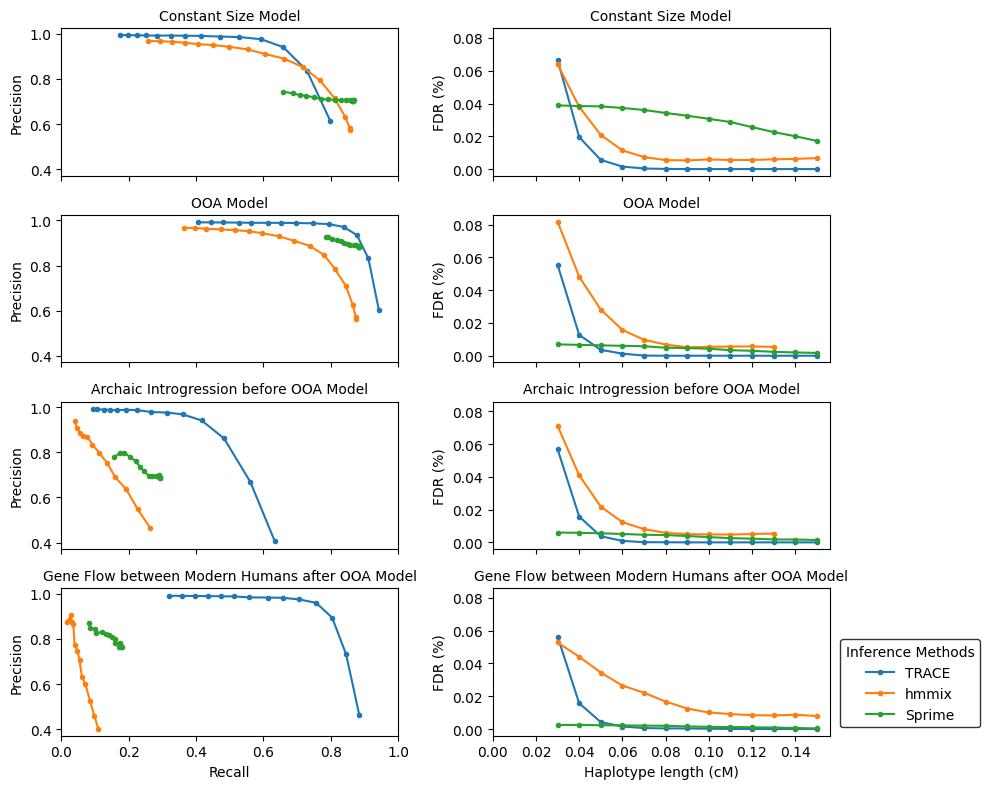

In [3]:
conf = yaml.safe_load(Path('../config/analysis.config.yaml').read_text())
seeds = conf['inference_comparison']['seeds']
n = conf['inference_comparison']['n']
pp_cutoff = conf['pp_cutoff']
l_cutoff = np.array(conf['l_cutoff'])
inference = conf['inference_comparison']['models']['split_constant']['inference'][:-1]
intro = conf['inference_comparison']['models']['split_constant']['intro'][0]
t = conf['inference_comparison']['models']['split_constant']['t'][0]

versions = ['m2_ori', 'm2_ori', 'intro_mha', 'm2_ori']
models = ['split_constant', 'ooa_neanderthal5r19_simp', 'ooa_neanderthal5r19_simp', 'ooa_neanderthal5r19_comp']
methods = ["TRACE", "hmmix", "Sprime"]
model_labels = ["Constant Size Model", "OOA Model", "Archaic Introgression before OOA Model", "Gene Flow between Modern Humans after OOA Model"]
markers = ['D', 'o', '^']
pps = [0.9, 0.8, 0.95]
colors=mcp.gen_color(cmap="tab10",n=10)
fig, ax = plt.subplots(4, 2, figsize=(10,8), sharey = 'col', sharex = 'col')
for j in range(len(versions)):
    for f in range(len(inference)):
        fpath = '../results/hmm_results/inference_comparison/'+str(models[j])+'/' + str(versions[j]) + '/' +str(inference[f]) + '/n' + str(n) + '_seed'
        t_archaic = str(intro)
        df = Figure_utils().merge_seeds(filepath=fpath, t_admix=t, t_archaic=t_archaic, seeds=seeds)
        precision, precision_err = Figure_utils().get_datapoints(df=df, colname='precision', ntime=30, pp_cutoff=pps[f], l_cutoff=l_cutoff)
        recall, recall_err = Figure_utils().get_datapoints(df=df, colname='recall', ntime=30, pp_cutoff=pps[f], l_cutoff=l_cutoff)
        if inference[f] == 'sprime':
            false_discovery, false_discovery_err = Figure_utils().get_datapoints(df=df, colname='false_discovery', ntime=30, pp_cutoff=pps[f], l_cutoff=l_cutoff)
            false_discovery = false_discovery * (0.02 * 250)
        else:
            false_discovery, false_discovery_err = Figure_utils().get_datapoints(df=df, colname='fdc_length', ntime=30, pp_cutoff=pps[f], l_cutoff=l_cutoff)
        if inference[f] == 'sprime':
            false_discovery = false_discovery / 10
            false_discovery_err = false_discovery_err / 10
#        ax[0].errorbar(recall, precision, xerr=recall_err, yerr=precision_err, marker=markers[1], markerfacecolor='none', markersize=5, color=colors[4*f + j],capsize=0, label=pps_label[4*f + j])
#        ax[1].errorbar(l_cutoff[3:], false_discovery[3:], yerr=false_discovery_err[3:], marker=markers[1], markerfacecolor='none', markersize=5, color=colors[4*f + j],capsize=0, label=pps_label[4*f + j])
        ax[j][0].plot(recall[precision > 0.4], precision[precision > 0.4], marker=markers[1], markersize=3, color=colors[f], label=methods[f])
        ax[j][1].plot(l_cutoff[3:], false_discovery[3:] / 25, marker=markers[1], markersize=3, color=colors[f], label=methods[f])
    ax[j][0].set_ylabel('Precision')
    ax[j][0].set_title(model_labels[j], fontsize=10)
    ax[j][1].set_ylabel('FDR (%)')
    ax[j][1].set_title(model_labels[j], fontsize=10)
legend1 = ax[3][1].legend(bbox_to_anchor=(1.01, 0.7), loc='upper left', title='Inference Methods')
frame2 = legend1.get_frame()
frame2.set_edgecolor('black')
# ax[0][0].set_ylim([0, 1.02])
ax[0][0].set_xlim([0, 1])
# formatter = ScalarFormatter()#useMathText=True)
# formatter.set_powerlimits((-2, -2))  # Force 1e4 notation
# ax[0][1].yaxis.set_major_formatter(formatter)
# ax[1][1].yaxis.set_major_formatter(formatter)
# ax[2][1].yaxis.set_major_formatter(formatter)
# ax[3][1].yaxis.set_major_formatter(formatter)
ax[0][1].set_xticks([0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14], ['0.00', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14'])
ax[3][0].set_xlabel('Recall')
ax[3][1].set_xlabel('Haplotype length (cM)')
plt.tight_layout()
plt.savefig('../images/fig2.pdf', bbox_inches='tight')

# Plot time estimations

In [4]:
all_gammas = []
all_t1s = []
all_t2s = []
all_treelen = []
all_nleaves = []
treespan = []
for s in range(1, 6):
    gammas = []
    t1s = []
    t2s = []
    nleaves = []
    treelen = []
    if s == 1:
        for i in range(10):
            data = np.load(f"../results/hmm_results/arg_infer/split_constant/m2_ori/msprime/n100_seed{s}_15000_0.02_A_ppsind{i}.npz")
            all_gammas.append(data["n_gamma"][1])
            all_t1s.append(data["at1s"])
            all_t2s.append(data["at2s"])
            all_nleaves.append(data["anleaves"])
            all_treelen.append(data["a_tree_span"][:, 1] - data["a_tree_span"][:, 0])
        all_gammas = np.array(all_gammas)
        all_t1s = np.array(all_t1s)
        all_t2s = np.array(all_t2s)
        all_nleaves = np.array(all_nleaves)
        all_treelen = np.array(all_treelen)
        treespan  = np.array(data["a_tree_span"])
    else:
        for i in range(10):
            data = np.load(f"../results/hmm_results/arg_infer/split_constant/m2_ori/msprime/n100_seed{s}_15000_0.02_A_ppsind{i}.npz")
            gammas.append(data["n_gamma"][1])
            t1s.append(data["at1s"])
            t2s.append(data["at2s"])
            nleaves.append(data["anleaves"])
            treelen.append(data["a_tree_span"][:, 1] - data["a_tree_span"][:, 0])
        gammas = np.array(gammas)
        t1s = np.array(t1s)
        t2s = np.array(t2s)
        nleaves = np.array(nleaves)
        treelen = np.array(treelen)
        treespan = np.concatenate((treespan, data["a_tree_span"]), axis=0)
        all_gammas = np.concatenate((all_gammas, gammas), axis=1)
        all_t1s = np.concatenate((all_t1s, t1s), axis=1)
        all_t2s = np.concatenate((all_t2s, t2s), axis=1)
        all_nleaves = np.concatenate((all_nleaves, nleaves), axis=1)
        all_treelen = np.concatenate((all_treelen, treelen), axis=1)

In [5]:
nboots = 50
func = np.median
nl_upper = 1
l_cutoff = [0.02, 0.03, 0.05, 0.07, 0.09, 0.11]
np.random.seed(1)
data_dict = {"l_cutoff":[], "t1s":[], "t2s_single":[], "t2s_mean":[], "t1s_q2.5":[], "t1s_q97.5":[], "t2s_single_q2.5":[], "t2s_single_q97.5":[], "t2s_mean_q2.5":[], "t2s_mean_q97.5":[]}
for l in l_cutoff:
    print(l)
    inferred, states = Performance_utils().filter_hmm_output(arc_cutoff=0.5,
        pp_cutoff=0.9,
        l_cutoff=l,
        popmerge=False,
        maxlen=None,
        combined_pp=all_gammas,
        treespan=treespan,
    )
    t_states = states[states > 0]
    t1s = all_t1s[states > 0]
    t2s = all_t2s[states > 0]
    nleaves = all_nleaves[states > 0]
    s_t1s = []
    sm_t2s = []
    s_t2s = []
    for ustate in np.unique(t_states):
        s_t1s.append(func(t1s[t_states == ustate]))
        sm_t2s.append(func(t2s[t_states == ustate]))
        subnl = nleaves[t_states == ustate]
        subt2s = t2s[t_states == ustate]
        s_t2s.append(func(subt2s[subnl < (nl_upper + 1)]))
    s_t1s = np.array(s_t1s)
    s_t2s = np.array(s_t2s)
    s_t2s = s_t2s[~np.isnan(s_t2s)]
    sm_t2s = np.array(sm_t2s)
    data_dict["l_cutoff"].append(l)
    data_dict["t1s"].append(np.mean(s_t1s))
    data_dict["t2s_single"].append(np.mean(s_t2s))
    data_dict["t2s_mean"].append(np.mean(sm_t2s))
    data_dict["t1s_q2.5"].append(np.percentile(s_t1s, 2.5))
    data_dict["t1s_q97.5"].append(np.percentile(s_t1s, 97.5))
    data_dict["t2s_single_q2.5"].append(np.percentile(s_t2s, 2.5))
    data_dict["t2s_single_q97.5"].append(np.percentile(s_t2s, 97.5))
    data_dict["t2s_mean_q2.5"].append(np.percentile(sm_t2s, 2.5))
    data_dict["t2s_mean_q97.5"].append(np.percentile(sm_t2s, 97.5))
df = pd.DataFrame.from_dict(data_dict)

0.02
0.03
0.05
0.07
0.09
0.11


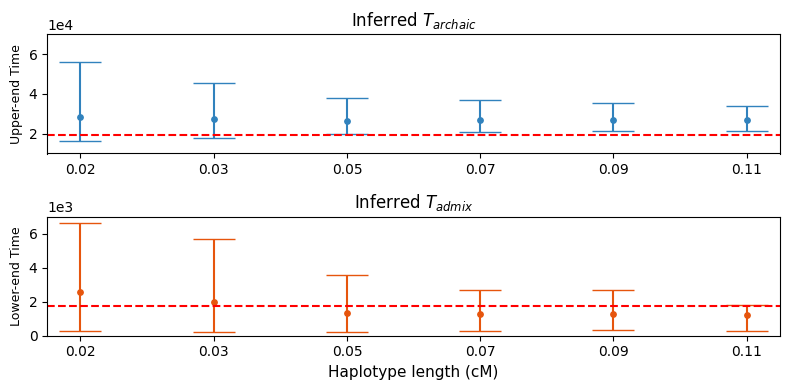

In [7]:
fig, ax = plt.subplots(2, 1, figsize = (8, 4))
colors=mcp.gen_color(cmap="tab20c",n=20)

lower = df['t2s_mean'] - df['t2s_mean_q2.5']
upper = df['t2s_mean_q97.5'] - df['t2s_mean']
ayerr = np.vstack([lower, upper])
ax[0].errorbar(range(6), df['t2s_mean'], yerr=ayerr, marker = 'o', markerfacecolor='none', markersize=0, color=colors[0],capsize=15, fmt = 'none')
ax[0].scatter(range(6), df['t2s_mean'], s =15, color = colors[0])

# lower = df['t2s_single'] - df['t2s_single_q2.5']
# upper = df['t2s_single_q97.5'] - df['t2s_single']
# byerr = np.vstack([lower, upper])
# ax[1].errorbar(range(6), df['t2s_single'], yerr=byerr, marker = 'o', markerfacecolor='none', markersize=0, color=colors[0],capsize=15, fmt = 'none')
# ax[1].scatter(range(6), df['t2s_single'], s = 15, color = colors[0])

lower = df['t1s'] - df['t1s_q2.5']
upper = df['t1s_q97.5'] - df['t1s']
cyerr = np.vstack([lower, upper])
ax[1].errorbar(range(6), df['t1s'], yerr=cyerr, marker = 'o', markerfacecolor='none', markersize=0, color=colors[4],capsize=15, fmt = 'none')
ax[1].scatter(range(6), df['t1s'], s = 15, color = colors[4])

ax[0].axhline(y=19275, color='red', linestyle='--')
ax[0].set_ylabel('Upper-end Time', fontsize=9)
# ax[1].axhline(y=19275, color='red', linestyle='--')
# ax[1].set_ylabel('Upper-end Time', fontsize=9)
ax[1].axhline(y=1724, color='red', linestyle='--')
ax[1].set_ylabel('Lower-end Time', fontsize=9)
formatter = ScalarFormatter()#useMathText=True)
formatter.set_powerlimits((4, 4))  # Force 1e4 notation
ax[0].yaxis.set_major_formatter(formatter)
# formatter = ScalarFormatter()#useMathText=True)
# formatter.set_powerlimits((4, 4))  # Force 1e4 notation
# ax[1].yaxis.set_major_formatter(formatter)
formatter1 = ScalarFormatter()#useMathText=True)
formatter1.set_powerlimits((3, 3))  # Force 1e4 notation
ax[1].yaxis.set_major_formatter(formatter1)

# ax[0].set_yscale('log')
ax[0].set_ylim([1e4, 7e4])
# ax[1].set_ylim([1e4, 7e4])
ax[1].set_ylim([0, 7e3])
# ax[0].set_xlabel('Haplotype length (cM)', fontsize=11)
# ax[1].set_xlabel('Haplotype length (cM)', fontsize=11)
ax[1].set_xlabel('Haplotype length (cM)', fontsize=11)
ax[0].set_xticks(range(6))
# ax[2].set_xticks(range(6))
ax[1].set_xticks(range(6))
ax[0].set_xticklabels(df['l_cutoff'].unique())
ax[1].set_xticklabels(df['l_cutoff'].unique())
# ax[2].set_xticklabels(df['l_cutoff'].unique())
# ax[1].set_title(r'Inferred $T_{archaic}$: mean over single-leaf branches')
ax[0].set_title(r'Inferred $T_{archaic}$')
ax[1].set_title(r'Inferred $T_{admix}$')
plt.tight_layout()
plt.savefig('../images/figS2_2.pdf', bbox_inches='tight')

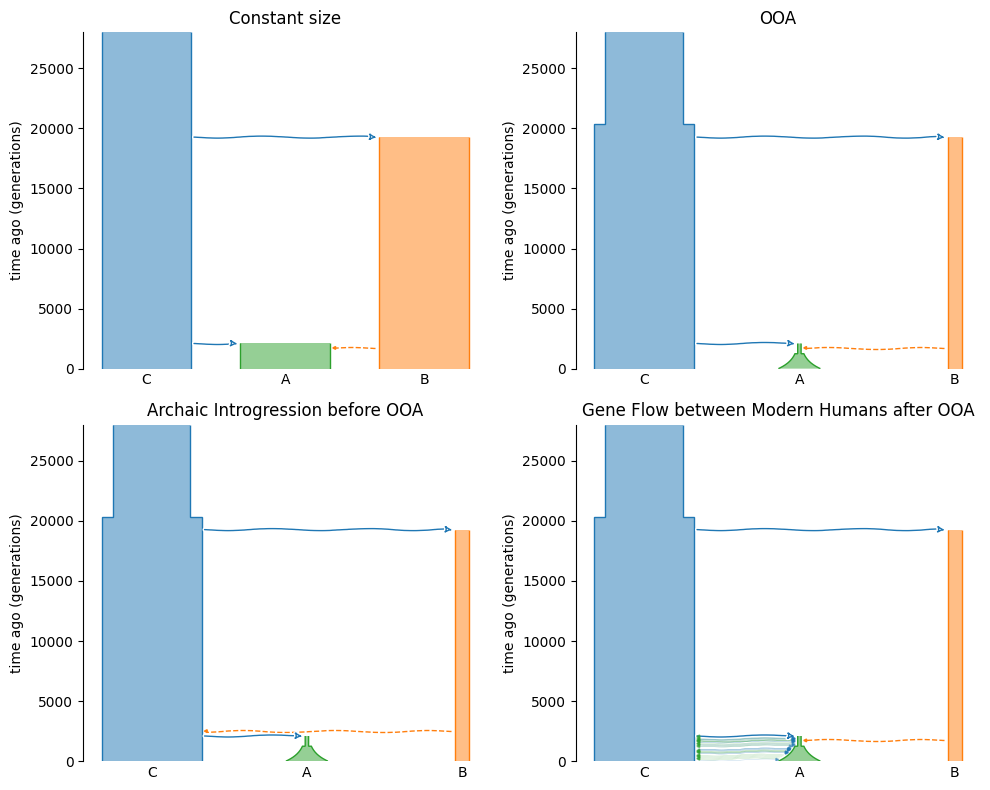

In [2]:
fig, ax = plt.subplots(2, 2, figsize=(10,8))
versions = ['m2_ori', 'm2_ori', 'intro_mha', 'm2_ori']
models = ['split_constant', 'ooa_neanderthal5r19_simp', 'ooa_neanderthal5r19_simp', 'ooa_neanderthal5r19_comp']
graph=demes.load("../data/template_models/"+str(models[0])+"_"+str(versions[0])+".yaml")
demesdraw.tubes(graph, ax=ax[0][0], title='Constant size', max_time=28000)
graph=demes.load("../data/template_models/"+str(models[1])+"_"+str(versions[1])+".yaml")
demesdraw.tubes(graph, ax=ax[0][1], title='OOA', max_time=28000)
graph=demes.load("../data/template_models/"+str(models[2])+"_"+str(versions[2])+".yaml")
demesdraw.tubes(graph, ax=ax[1][0], title='Archaic Introgression before OOA', max_time=28000)
graph=demes.load("../data/template_models/"+str(models[3])+"_"+str(versions[3])+".yaml")
demesdraw.tubes(graph, ax=ax[1][1], title='Gene Flow between Modern Humans after OOA', max_time=28000)
fig.tight_layout()
plt.savefig('../images/figS2_1.pdf', bbox_inches='tight')

# Plot performance over input sample size & pp values

In [5]:
conf = yaml.safe_load(Path('../config/analysis.config.yaml').read_text())
# model = 'ooa_neanderthal5r19_simp'
model = 'split_constant'
# version = conf['inference_comparison']['models'][model]['versions'][0]
versions = conf['inference_range']['models'][model]['versions'][:-1]
seeds = conf['inference_range']['seeds']
# seeds=[10]
# 2, 5, 9
n = conf['inference_range']['n']
pp_cutoff = conf['pp_cutoff']
l_cutoff = conf['l_cutoff']
intros = conf['inference_range']['models'][model]['intro']

/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:929: RuntimeWarning: Mean of empty slice
  out.append(np.nanmean(pres))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:929: RuntimeWarning: Mean of empty slice
  out.append(np.nanmean(pres))
/global/scratch/user

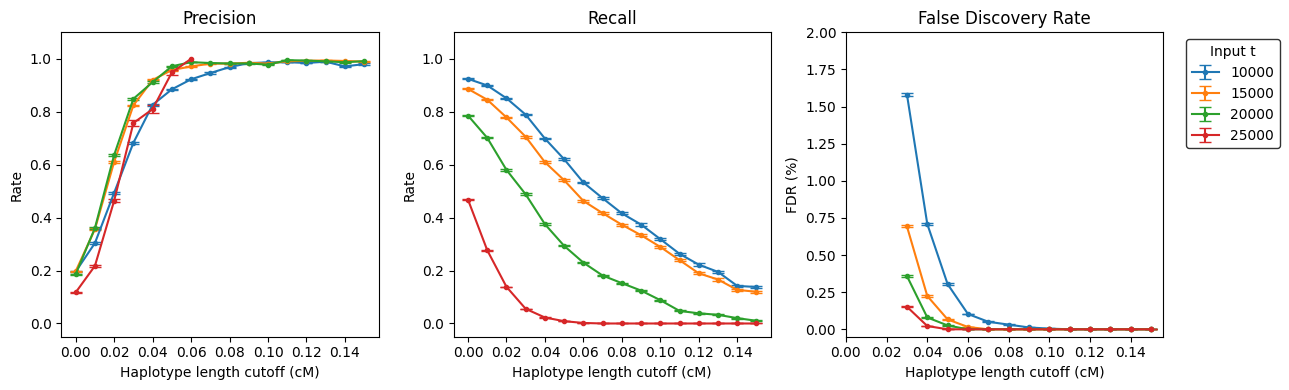

In [8]:
ts = conf['error_input']['models'][model]['t']
ts = ts[1:]
l_cutoff = conf['l_cutoff']
pps_label = ['> 0.8','> 0.9','> 0.95']
colors=mcp.gen_color(cmap="tab10",n=10)
linestyles = ['-', '--', ':', '-.', ]
fig, ax = plt.subplots(1, 3, figsize=(13,4), constrained_layout=True)#, sharey=True)
n=100
intro=0.02
version = 'm2_ori'
ppf=0.9
dashList = [(),(3, 1),(1, 2),(5, 2, 1, 2),(3, 1, 1, 1, 1, 1)]
for t in range(len(ts)):
    # merge seeds
    fpath = '../results/hmm_results/error_input/'+str(model)+'/' + str(version) + '/n' + str(n) + '_seed'
    t_archaic = str(intro)
    df = Figure_utils().merge_seeds(filepath=fpath, t_admix=ts[t], t_archaic=t_archaic, seeds=[1,2,3])
    precision, precision_err = Figure_utils().get_datapoints(df=df, colname='precision', ntime=30, pp_cutoff=ppf, l_cutoff=l_cutoff)
    recall, recall_err = Figure_utils().get_datapoints(df=df, colname='recall', ntime=30, pp_cutoff=ppf, l_cutoff=l_cutoff)
    false_discovery, false_discovery_err = Figure_utils().get_datapoints(df=df, colname='false_discovery', ntime=30, pp_cutoff=ppf, l_cutoff=l_cutoff)
    ax[0].errorbar(l_cutoff, precision, yerr=precision_err, fmt=linestyles[0],marker='o',markersize=3, color=colors[t],capsize=4)
    ax[1].errorbar(l_cutoff, recall, yerr=recall_err, fmt=linestyles[0],marker='o',markersize=3, color=colors[t],capsize=4)
    ax[2].errorbar(l_cutoff[3:], false_discovery[3:] *2, yerr=false_discovery_err[3:] *2, fmt=linestyles[0],marker='o',markersize=3, color=colors[t],capsize=4, label = ts[t])
ax[0].set_ylabel('Rate')
ax[1].set_ylabel('Rate')
ax[2].set_ylabel('FDR (%)')
ax[0].set_xlabel('Haplotype length cutoff (cM)')
ax[1].set_xlabel('Haplotype length cutoff (cM)')
ax[2].set_xlabel('Haplotype length cutoff (cM)')
legend1 = ax[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Input t')
frame1 = legend1.get_frame()
frame1.set_edgecolor('black')
fig.tight_layout()
ax[0].set_xticks([0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14], ['0.00', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14'])
ax[1].set_xticks([0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14], ['0.00', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14'])
ax[2].set_xticks([0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14], ['0.00', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14'])
ax[0].set_ylim([-0.05, 1.1])
ax[1].set_ylim([-0.05, 1.1])
ax[2].set_ylim([-0.05, 2])
ax[0].set_title('Precision')
ax[1].set_title('Recall')
ax[2].set_title('False Discovery Rate')
plt.tight_layout()
plt.savefig('../images/figS1_2.pdf', bbox_inches='tight')

/global/scratch/users/zhangyulin9806/tmp/ipykernel_1600292/3858599868.py:81: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


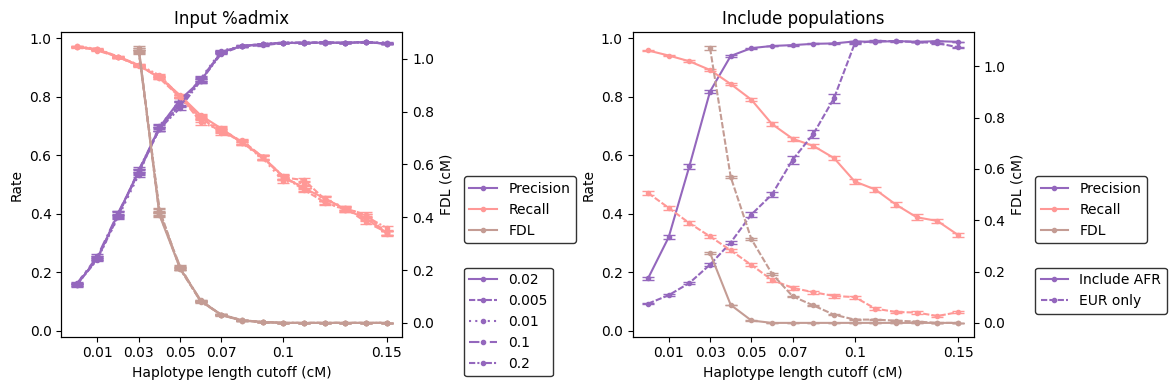

In [6]:
l_cutoff = conf['l_cutoff']
pps_label = ['> 0.8','> 0.9','> 0.95']
colors=mcp.gen_color(cmap="tab20",n=20)
linestyles = ['-', '--', ':', '-.', ]
fig, ax = plt.subplots(1, 2, figsize=(12,4), constrained_layout=True)

# graph=demes.load("../results/simulations/models/"+str(model)+"/"+str(model)+"_"+str(version)+".yaml")
# demesdraw.tubes(graph, ax=ax[0], max_time=28000)

n=100
intro=[0.02, 0.005, 0.01, 0.1, 0.2]
version = 'm2_ori'
ppf=0.9
tt = 10000
dashList = [(),(3, 1),(1, 2),(5, 2, 1, 2),(3, 1, 1, 1, 1, 1)]
ax2 = ax[0].twinx()
ax2.set_ylabel('FDL (cM)')
for t in range(len(intro)):
    # merge seeds
    fpath = '../results/hmm_results/error_input/'+str(model)+'/' + str(version) + '/n' + str(n) + '_seed'
    t_archaic = str(intro[t])
    df = Figure_utils().merge_seeds(filepath=fpath, t_admix=tt, t_archaic=t_archaic, seeds=[1,2,3])
    precision, precision_err = Figure_utils().get_datapoints(df=df, colname='precision', ntime=30, pp_cutoff=ppf, l_cutoff=l_cutoff)
    recall, recall_err = Figure_utils().get_datapoints(df=df, colname='recall', ntime=30, pp_cutoff=ppf, l_cutoff=l_cutoff)
    false_discovery, false_discovery_err = Figure_utils().get_datapoints(df=df, colname='fdc_length', ntime=30, pp_cutoff=ppf, l_cutoff=l_cutoff)
    ax[0].errorbar(l_cutoff, precision, yerr=precision_err, fmt="--", dashes=dashList[t],marker='o',markersize=3, color=colors[8],capsize=4)
    ax[0].errorbar(l_cutoff, recall, yerr=recall_err, fmt="--", dashes=dashList[t],marker='o',markersize=3, color=colors[7],capsize=4)
    ax2.errorbar(l_cutoff[3:], false_discovery[3:], yerr=false_discovery_err[3:], fmt="--", dashes=dashList[t],marker='o',markersize=3, color=colors[11],capsize=4)
ax[0].set_ylabel('Rate')
ax[0].set_xlabel('Haplotype length cutoff (cM)')
ax[0].set_title('Input %admix')
ax[0].set_ylim([-0.02, 1.02])
s = ax2.get_lines()
lines = ax[0].get_lines()
legend1 = ax[0].legend([lines[0], lines[3], s[0]], ['Precision','Recall','FDL'], bbox_to_anchor=(1.16, 0.55), loc='upper left')
frame1 = legend1.get_frame()
frame1.set_edgecolor('black')
legend2 = ax[0].legend([lines[i] for i in [0,6,12,18,24]], intro, bbox_to_anchor=(1.16, 0.25), loc='upper left')
frame2 = legend2.get_frame()
frame2.set_edgecolor('black')
ax[0].add_artist(legend1)
# ax[0].set_xscale('log')
ax[0].set_xticks([0.01, 0.03, 0.05, 0.07, 0.1, 0.15], ['0.01', '0.03', '0.05', '0.07', '0.1', '0.15'])

n=100
intro=[0.02, '0.02_A']
intro_label = ['Include AFR', 'EUR only']
version = 'm2_ori'
ppf=0.9
tt = 15000
dashList = [(),(3, 1),(1, 2),(5, 2, 1, 2),(3, 1, 1, 1, 1, 1)]
ax2 = ax[1].twinx()
ax2.set_ylabel('FDL (cM)')
for t in range(len(intro)):
    # merge seeds
    fpath = '../results/hmm_results/error_input/'+str(model)+'/' + str(version) + '/n' + str(n) + '_seed'
    t_archaic = str(intro[t])
    df = Figure_utils().merge_seeds(filepath=fpath, t_admix=tt, t_archaic=t_archaic, seeds=[1,2,3])
    precision, precision_err = Figure_utils().get_datapoints(df=df, colname='precision', ntime=30, pp_cutoff=ppf, l_cutoff=l_cutoff)
    recall, recall_err = Figure_utils().get_datapoints(df=df, colname='recall', ntime=30, pp_cutoff=ppf, l_cutoff=l_cutoff)
    false_discovery, false_discovery_err = Figure_utils().get_datapoints(df=df, colname='fdc_length', ntime=30, pp_cutoff=ppf, l_cutoff=l_cutoff)
    ax[1].errorbar(l_cutoff, precision, yerr=precision_err, fmt="--", dashes=dashList[t],marker='o',markersize=3, color=colors[8],capsize=4)
    ax[1].errorbar(l_cutoff, recall, yerr=recall_err, fmt="--", dashes=dashList[t],marker='o',markersize=3, color=colors[7],capsize=4)
    ax2.errorbar(l_cutoff[3:], false_discovery[3:], yerr=false_discovery_err[3:], fmt="--", dashes=dashList[t],marker='o',markersize=3, color=colors[11],capsize=4)
ax[1].set_ylabel('Rate')
ax[1].set_xlabel('Haplotype length cutoff (cM)')
ax[1].set_title('Include populations')
ax[1].set_ylim([-0.02, 1.02])
s = ax2.get_lines()
lines = ax[1].get_lines()
legend1 = ax[1].legend([lines[0], lines[3], s[0]], ['Precision','Recall','FDL'], bbox_to_anchor=(1.16, 0.55), loc='upper left')
frame1 = legend1.get_frame()
frame1.set_edgecolor('black')
legend2 = ax[1].legend([lines[i] for i in [0,6]], intro_label, bbox_to_anchor=(1.16, 0.25), loc='upper left')
frame2 = legend2.get_frame()
frame2.set_edgecolor('black')
ax[1].add_artist(legend1)
# ax[0].set_xscale('log')
ax[1].set_xticks([0.01, 0.03, 0.05, 0.07, 0.1, 0.15], ['0.01', '0.03', '0.05', '0.07', '0.1', '0.15'])

fig.tight_layout()

/global/scratch/users/zhangyulin9806/tmp/ipykernel_289882/3356915727.py:153: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


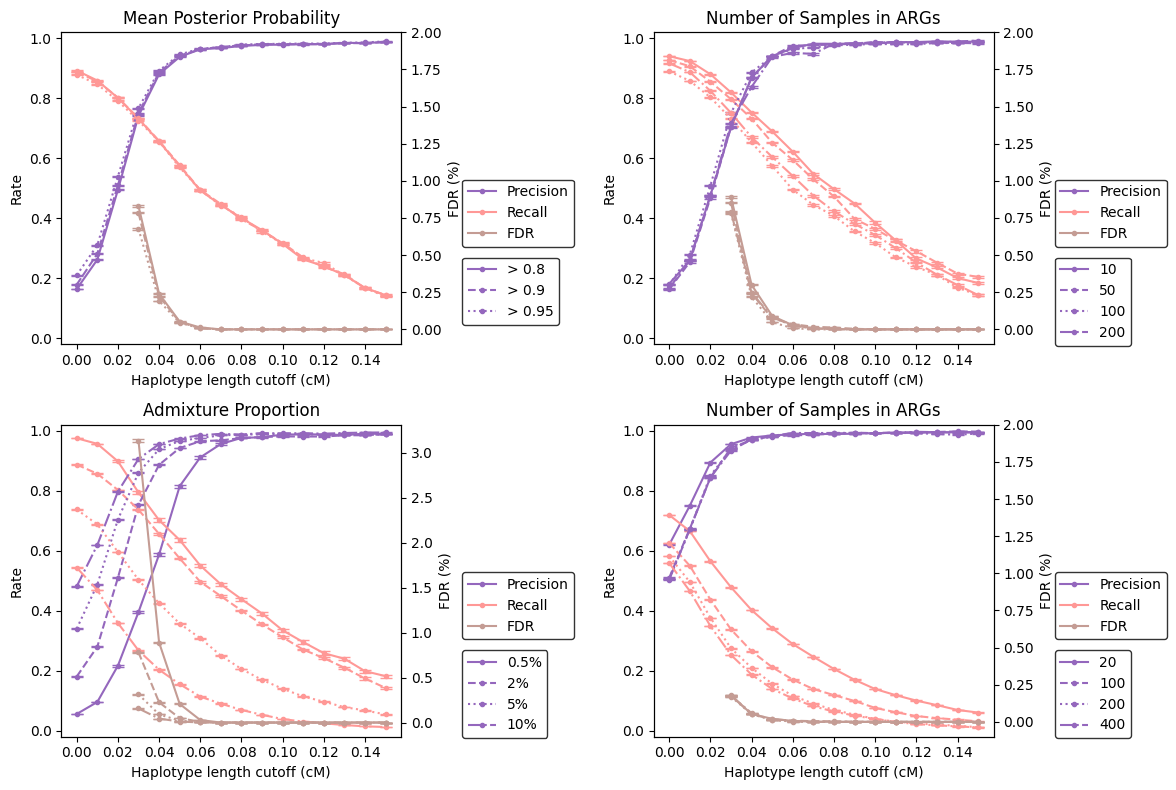

In [9]:
l_cutoff = conf['l_cutoff']
pps_label = ['> 0.8','> 0.9','> 0.95']
colors=mcp.gen_color(cmap="tab20",n=20)
linestyles = ['-', '--', ':', '-.', ]
fig, ax = plt.subplots(2, 2, figsize=(12,8), constrained_layout=True)

# graph=demes.load("../results/simulations/models/"+str(model)+"/"+str(model)+"_"+str(version)+".yaml")
# demesdraw.tubes(graph, ax=ax[0], max_time=28000)


n=100
intro="0.02_A"
version = 'm2_ori'
t = 15000
ax2 = ax[0][0].twinx()
ax2.set_ylabel('FDR (%)')
ax2.set_ylim([-0.1, 2])
for f in range(len(pp_cutoff)):
    # merge seeds
    fpath = '../results/hmm_results/inference_range/'+str(model)+'/' + str(version) + '/n' + str(n) + '_seed'
    t_archaic = str(intro)
    df = Figure_utils().merge_seeds(filepath=fpath, t_admix=t, t_archaic=t_archaic, seeds=seeds)
    precision, precision_err = Figure_utils().get_datapoints(df=df, colname='precision', ntime=30, pp_cutoff=pp_cutoff[f], l_cutoff=l_cutoff)
    recall, recall_err = Figure_utils().get_datapoints(df=df, colname='recall', ntime=30, pp_cutoff=pp_cutoff[f], l_cutoff=l_cutoff)
    false_discovery, false_discovery_err = Figure_utils().get_datapoints(df=df, colname='false_discovery', ntime=30, pp_cutoff=pp_cutoff[f], l_cutoff=l_cutoff)
    ax[0][0].errorbar(l_cutoff, precision, yerr=precision_err, fmt=linestyles[f],marker='o',markersize=3, color=colors[8],capsize=4)
    ax[0][0].errorbar(l_cutoff, recall, yerr=recall_err, fmt=linestyles[f],marker='o',markersize=3, color=colors[7],capsize=4)
    ax2.errorbar(l_cutoff[3:], false_discovery[3:] *2, yerr=false_discovery_err[3:] *2, fmt=linestyles[f],marker='o',markersize=3, color=colors[11],capsize=4)
ax[0][0].set_ylabel('Rate')
ax[0][0].set_xlabel('Haplotype length cutoff (cM)')
ax[0][0].set_title('Mean Posterior Probability')
ax[0][0].set_ylim([-0.02, 1.02])
s = ax2.get_lines()
lines = ax[0][0].get_lines()
legend2 = ax[0][0].legend([lines[i] for i in [0,6,12]], pps_label, bbox_to_anchor=(1.16, 0.3), loc='upper left')
frame2 = legend2.get_frame()
frame2.set_edgecolor('black')
legend1 = ax[0][0].legend([lines[0], lines[3], s[0]], ['Precision','Recall','FDR'], bbox_to_anchor=(1.16, 0.55), loc='upper left')
frame1 = legend1.get_frame()
frame1.set_edgecolor('black')
ax[0][0].add_artist(legend2)


sampsize=['10', '50', '100', '200']
sampsize_label=['20', '100', '200', '400']
intro="0.02_A"
version = 'm2_ori'
t = 15000
ax2 = ax[0][1].twinx()
ax2.set_ylabel('FDR (%)')
ax2.set_ylim([-0.1, 2])
for f in range(len(sampsize)):
    # merge seeds
    fpath = '../results/hmm_results/inference_range/'+str(model)+'/' + str(version) + '/n' + str(sampsize[f]) + '_seed'
    t_archaic = str(intro)
    df = Figure_utils().merge_seeds(filepath=fpath, t_admix=t, t_archaic=t_archaic, seeds=seeds)
    precision, precision_err = Figure_utils().get_datapoints(df=df, colname='precision', ntime=30, pp_cutoff=pp_cutoff[1], l_cutoff=l_cutoff)
    recall, recall_err = Figure_utils().get_datapoints(df=df, colname='recall', ntime=30, pp_cutoff=pp_cutoff[1], l_cutoff=l_cutoff)
    false_discovery, false_discovery_err = Figure_utils().get_datapoints(df=df, colname='false_discovery', ntime=30, pp_cutoff=pp_cutoff[1], l_cutoff=l_cutoff)
    ax[0][1].errorbar(l_cutoff, precision, yerr=precision_err, fmt=linestyles[f],marker='o',markersize=3, color=colors[8],capsize=4)
    ax[0][1].errorbar(l_cutoff, recall, yerr=recall_err, fmt=linestyles[f],marker='o',markersize=3, color=colors[7],capsize=4)
    ax2.errorbar(l_cutoff[3:], false_discovery[3:] *2, yerr=false_discovery_err[3:] *2, fmt=linestyles[f],marker='o',markersize=3, color=colors[11],capsize=4)
ax[0][1].set_ylabel('Rate')
ax[0][1].set_xlabel('Haplotype length cutoff (cM)')
ax[0][1].set_title('Number of Samples in ARGs')
ax[0][1].set_ylim([-0.02, 1.02])
s = ax2.get_lines()
lines = ax[0][1].get_lines()
legend2 = ax[0][1].legend([lines[i] for i in [0,6,12, 18]], sampsize, bbox_to_anchor=(1.16, 0.3), loc='upper left')
frame2 = legend2.get_frame()
frame2.set_edgecolor('black')
legend1 = ax[0][1].legend([lines[0], lines[3], s[0]], ['Precision','Recall','FDR'], bbox_to_anchor=(1.16, 0.55), loc='upper left')
frame1 = legend1.get_frame()
frame1.set_edgecolor('black')
ax[0][1].add_artist(legend2)

n=100
ppf=0.9
t = 15000
ax2 = ax[1][0].twinx()
ax2.set_ylabel('FDR (%)')
#ax2.set_ylim([-0.05, 0.1])
versions = ['m0.5_ori', 'm2_ori', 'm5_ori', 'm10_ori']
intros = [0.005, 0.02, 0.05, 0.1]
intros_label = ['0.5%', '2%', '5%', '10%']
#dashList = [(),(3, 1),(1, 2),(5, 2, 1, 2),(3, 1, 1, 1, 1, 1)]
for f, version in enumerate(versions):
    # merge seeds
    fpath = '../results/hmm_results/inference_range/'+str(model)+'/' + str(version) + '/n' + str(n) + '_seed'
    t_archaic = str(intros[f]) + "_A"
    df = Figure_utils().merge_seeds(filepath=fpath, t_admix=t, t_archaic=t_archaic, seeds=seeds)
    precision, precision_err = Figure_utils().get_datapoints(df=df, colname='precision', ntime=30, pp_cutoff=ppf, l_cutoff=l_cutoff)
    recall, recall_err = Figure_utils().get_datapoints(df=df, colname='recall', ntime=30, pp_cutoff=ppf, l_cutoff=l_cutoff)
    false_discovery, false_discovery_err = Figure_utils().get_datapoints(df=df, colname='false_discovery', ntime=30, pp_cutoff=ppf, l_cutoff=l_cutoff)
    # ax[2].errorbar(l_cutoff, precision, yerr=precision_err, fmt="--", dashes = dashList[f],marker='o',markersize=3, color=colors[8],capsize=4)
    # ax[2].errorbar(l_cutoff, recall, yerr=recall_err, fmt="--", dashes = dashList[f],marker='o',markersize=3, color=colors[7],capsize=4)
    # ax2.errorbar(l_cutoff[2:], false_discovery[2:] / 50, yerr=false_discovery_err[2:] / 50, fmt="--", dashes = dashList[f],marker='o',markersize=3, color=colors[11],capsize=4)
    ax[1][0].errorbar(l_cutoff, precision, yerr=precision_err, fmt=linestyles[f],marker='o',markersize=3, color=colors[8],capsize=4)
    ax[1][0].errorbar(l_cutoff, recall, yerr=recall_err, fmt=linestyles[f],marker='o',markersize=3, color=colors[7],capsize=4)
    ax2.errorbar(l_cutoff[3:], false_discovery[3:] *2, yerr=false_discovery_err[3:] *2, fmt=linestyles[f],marker='o',markersize=3, color=colors[11],capsize=4)
ax[1][0].set_ylabel('Rate')
ax[1][0].set_xlabel('Haplotype length cutoff (cM)')
ax[1][0].set_title('Admixture Proportion')
ax[1][0].set_ylim([-0.02, 1.02])
s = ax2.get_lines()
lines = ax[1][0].get_lines()
legend2 = ax[1][0].legend([lines[i] for i in [0,6,12,18]], intros_label, bbox_to_anchor=(1.16, 0.3), loc='upper left')
frame2 = legend2.get_frame()
frame2.set_edgecolor('black')
legend1 = ax[1][0].legend([lines[0], lines[3], s[0]], ['Precision','Recall','FDR'], bbox_to_anchor=(1.16, 0.55), loc='upper left')
frame1 = legend1.get_frame()
frame1.set_edgecolor('black')
ax[1][0].add_artist(legend2)

sampsize=['10', '50', '100', '200']
sampsize_label=['20', '100', '200', '400']
intro="0.1"
version = 'm10_ori'
t = 15000
ax2 = ax[1][1].twinx()
ax2.set_ylabel('FDR (%)')
ax2.set_ylim([-0.1, 2])
for f in range(len(sampsize)):
    # merge seeds
    fpath = '../results/hmm_results/inference_range/'+str(model)+'/' + str(version) + '/n' + str(sampsize[f]) + '_seed'
    t_archaic = str(intro)
    df = Figure_utils().merge_seeds(filepath=fpath, t_admix=t, t_archaic=t_archaic, seeds=seeds)
    precision, precision_err = Figure_utils().get_datapoints(df=df, colname='precision', ntime=30, pp_cutoff=pp_cutoff[1], l_cutoff=l_cutoff)
    recall, recall_err = Figure_utils().get_datapoints(df=df, colname='recall', ntime=30, pp_cutoff=pp_cutoff[1], l_cutoff=l_cutoff)
    false_discovery, false_discovery_err = Figure_utils().get_datapoints(df=df, colname='false_discovery', ntime=30, pp_cutoff=pp_cutoff[1], l_cutoff=l_cutoff)
    ax[1][1].errorbar(l_cutoff, precision, yerr=precision_err, fmt=linestyles[f],marker='o',markersize=3, color=colors[8],capsize=4)
    ax[1][1].errorbar(l_cutoff, recall, yerr=recall_err, fmt=linestyles[f],marker='o',markersize=3, color=colors[7],capsize=4)
    ax2.errorbar(l_cutoff[3:], false_discovery[3:] *2, yerr=false_discovery_err[3:] *2, fmt=linestyles[f],marker='o',markersize=3, color=colors[11],capsize=4)
ax[1][1].set_ylabel('Rate')
ax[1][1].set_xlabel('Haplotype length cutoff (cM)')
ax[1][1].set_title('Number of Samples in ARGs')
ax[1][1].set_ylim([-0.02, 1.02])
s = ax2.get_lines()
lines = ax[1][1].get_lines()
legend2 = ax[1][1].legend([lines[i] for i in [0,6,12, 18]], sampsize_label, bbox_to_anchor=(1.16, 0.3), loc='upper left')
frame2 = legend2.get_frame()
frame2.set_edgecolor('black')
legend1 = ax[1][1].legend([lines[0], lines[3], s[0]], ['Precision','Recall','FDR'], bbox_to_anchor=(1.16, 0.55), loc='upper left')
frame1 = legend1.get_frame()
frame1.set_edgecolor('black')
ax[1][1].add_artist(legend2)

ax[0][0].set_xticks([0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14], ['0.00', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14'])
ax[0][1].set_xticks([0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14], ['0.00', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14'])
ax[1][0].set_xticks([0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14], ['0.00', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14'])
ax[1][1].set_xticks([0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14], ['0.00', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14'])

fig.tight_layout()
plt.savefig('../images/figS2_3.pdf', bbox_inches='tight')

/global/scratch/users/zhangyulin9806/tmp/ipykernel_3557410/523172246.py:72: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


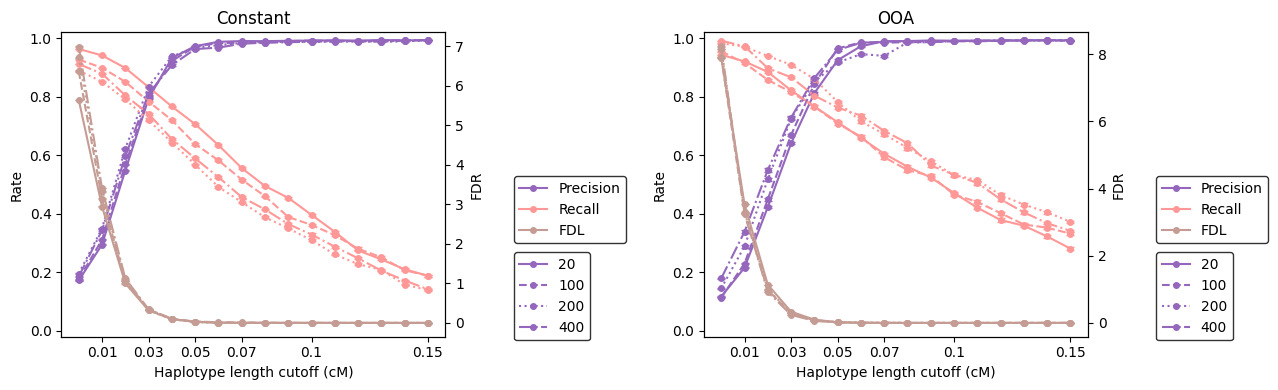

In [18]:
# seeds = range(1, 11)
# seeds = [7]
l_cutoff = conf['l_cutoff']
pps_label = ['> 0.8','> 0.9','> 0.95']
colors=mcp.gen_color(cmap="tab20",n=20)
linestyles = ['-', '--', ':', '-.']
fig, ax = plt.subplots(1, 2, figsize=(13,4), constrained_layout=True)

sampsize=['10', '50', '100', '200']
sampsize_label=['20', '100', '200','400']
intro=0.02
version = 'm2_ori'
t = 15000
ax2 = ax[0].twinx()
ax2.set_ylabel('FDR')
for f in range(len(sampsize)):
    # merge seeds
    fpath = '../results/hmm_results/inference_range/split_constant/' + str(version) + '/n' + str(sampsize[f]) + '_seed'
    t_archaic = str(intro)
    df = Figure_utils().merge_seeds(filepath=fpath, t_admix=t, t_archaic=t_archaic, seeds=seeds)
    precision, precision_err = Figure_utils().get_datapoints(df=df, colname='precision', ntime=30, pp_cutoff=pp_cutoff[1], l_cutoff=l_cutoff)
    recall, recall_err = Figure_utils().get_datapoints(df=df, colname='recall', ntime=30, pp_cutoff=pp_cutoff[1], l_cutoff=l_cutoff)
    false_discovery, false_discovery_err = Figure_utils().get_datapoints(df=df, colname='fdc_length', ntime=30, pp_cutoff=pp_cutoff[1], l_cutoff=l_cutoff)
    ax[0].errorbar(l_cutoff, precision, yerr=precision_err, fmt=linestyles[f],marker='o',markersize=3, color=colors[8],capsize=4)
    ax[0].errorbar(l_cutoff, recall, yerr=recall_err, fmt=linestyles[f],marker='o',markersize=3, color=colors[7],capsize=4)
    ax2.errorbar(l_cutoff, false_discovery / (0.02 * 50), yerr=false_discovery_err/ (0.02 * 50), fmt=linestyles[f],marker='o',markersize=3, color=colors[11],capsize=4)
ax[0].set_ylabel('Rate')
ax[0].set_xlabel('Haplotype length cutoff (cM)')
ax[0].set_title('Constant')
ax[0].set_ylim([-0.02, 1.02])
s = ax2.get_lines()
lines = ax[0].get_lines()
legend2 = ax[0].legend([lines[i] for i in [0,6,12,18]], sampsize_label, bbox_to_anchor=(1.16, 0.3), loc='upper left')
frame2 = legend2.get_frame()
frame2.set_edgecolor('black')
legend1 = ax[0].legend([lines[0], lines[3], s[0]], ['Precision','Recall','FDL'], bbox_to_anchor=(1.16, 0.55), loc='upper left')
frame1 = legend1.get_frame()
frame1.set_edgecolor('black')
ax[0].add_artist(legend2)
# ax[1].set_xscale('log')
ax[0].set_xticks([0.01, 0.03, 0.05, 0.07, 0.1, 0.15], ['0.01', '0.03', '0.05', '0.07', '0.1', '0.15'])

ax2 = ax[1].twinx()
ax2.set_ylabel('FDR')
for f in range(len(sampsize)):
    # merge seeds
    fpath = '../results/hmm_results/inference_range/ooa_neanderthal5r19_simp/' + str(version) + '/n' + str(sampsize[f]) + '_seed'
    t_archaic = str(intro)
    df = Figure_utils().merge_seeds(filepath=fpath, t_admix=t, t_archaic=t_archaic, seeds=seeds)
    precision, precision_err = Figure_utils().get_datapoints(df=df, colname='precision', ntime=30, pp_cutoff=pp_cutoff[1], l_cutoff=l_cutoff)
    recall, recall_err = Figure_utils().get_datapoints(df=df, colname='recall', ntime=30, pp_cutoff=pp_cutoff[1], l_cutoff=l_cutoff)
    false_discovery, false_discovery_err = Figure_utils().get_datapoints(df=df, colname='fdc_length', ntime=30, pp_cutoff=pp_cutoff[1], l_cutoff=l_cutoff)
    ax[1].errorbar(l_cutoff, precision, yerr=precision_err, fmt=linestyles[f],marker='o',markersize=3, color=colors[8],capsize=4)
    ax[1].errorbar(l_cutoff, recall, yerr=recall_err, fmt=linestyles[f],marker='o',markersize=3, color=colors[7],capsize=4)
    ax2.errorbar(l_cutoff, false_discovery / (0.02 * 50), yerr=false_discovery_err/ (0.02 * 50), fmt=linestyles[f],marker='o',markersize=3, color=colors[11],capsize=4)
ax[1].set_ylabel('Rate')
ax[1].set_xlabel('Haplotype length cutoff (cM)')
ax[1].set_title('OOA')
ax[1].set_ylim([-0.02, 1.02])
s = ax2.get_lines()
lines = ax[1].get_lines()
legend2 = ax[1].legend([lines[i] for i in [0,6,12,18]], sampsize_label, bbox_to_anchor=(1.16, 0.3), loc='upper left')
frame2 = legend2.get_frame()
frame2.set_edgecolor('black')
legend1 = ax[1].legend([lines[0], lines[3], s[0]], ['Precision','Recall','FDL'], bbox_to_anchor=(1.16, 0.55), loc='upper left')
frame1 = legend1.get_frame()
frame1.set_edgecolor('black')
ax[1].add_artist(legend2)
# ax[1].set_xscale('log')
ax[1].set_xticks([0.01, 0.03, 0.05, 0.07, 0.1, 0.15], ['0.01', '0.03', '0.05', '0.07', '0.1', '0.15'])

fig.tight_layout()

# Plot performance of ARG inference methods

In [51]:
conf = yaml.safe_load(Path('../config/analysis.config.yaml').read_text())
model = 'ooa_neanderthal5r19_simp'
# model = 'split_constant'
version = conf['arg_infer']['models'][model]['versions'][1]
seeds = range(1, 11)
t = conf['arg_infer']['models'][model]['t']
pp_cutoff = conf['pp_cutoff'][1]
l_cutoff = conf['l_cutoff']
n = conf['arg_infer']['n']
intro = conf['arg_infer']['models'][model]['intro'][0]

/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:929: RuntimeWarning: Mean of empty slice
  out.append(np.nanmean(pres))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zh

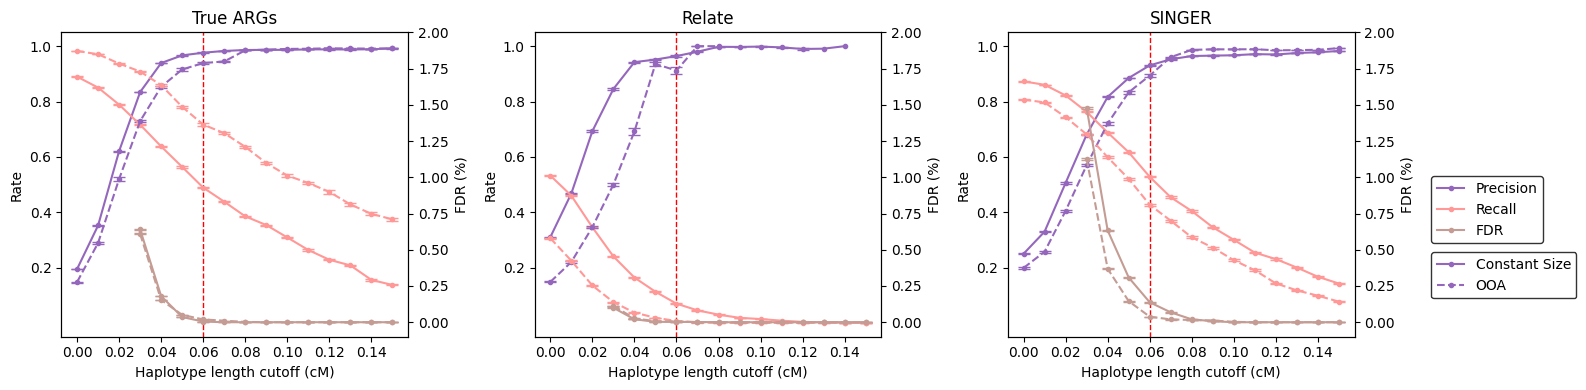

In [52]:
colors=mcp.gen_color(cmap="tab20",n=20)
cll = [colors[2], colors[4], colors[12], colors[8], colors[7]]
t = 15000 #[15000, 10000]
# 
# labels2=['0.02, 3600', '0.05, 3600', '0.1, 3600', '0.2, 3600', '0.02, 100', '0.02, 10000']
fig_utils = Figure_utils()
fig, ax = plt.subplots(1, 3, figsize=(16,4), sharey = 'all', sharex = 'all')
linestyles = ['-', '--', ':', '-.']
inference = ['msprime', 'relate', 'singer']
versions = ['m2_ori', 'm2_ori']#, 'm2_ori', 'intro_mha']
models = ['split_constant', 'ooa_neanderthal5r19_simp']#, 'ooa_neanderthal5r19_comp', 'ooa_neanderthal5r19_simp']
deme_label = ['Constant Size', 'OOA', 'Gene flow after OOA', 'Introgression before OOA']
# pps_label = ['True ARGs, Vanilla', 'True ARGs, OOA']#, 'True ARGs, Introgression before OOA', 'True ARGs, Gene flow after OOA'] 
# pps_label = pps_label + ['Relate, Vanilla', 'Relate, OOA']#, 'Relate, Introgression before OOA', 'Relate, Gene flow after OOA']
# pps_label = pps_label + ['SINGER, Vanilla', 'SINGER, OOA']#, 'SINGER, Introgression before OOA', 'SINGER, Gene flow after OOA']

for ii, f in enumerate(inference):
    ax2 = ax[ii].twinx()
    ax2.set_ylabel('FDR (%)')
    ax2.set_ylim([-0.1, 2])
    for j in range(len(versions)):
        fpath = '../results/hmm_results/arg_infer/'+str(models[j])+'/' + str(versions[j]) + '/' + str(f) + '/n' + str(n) + '_seed'
        t_archaic = str(intro)
        df = Figure_utils().merge_seeds(filepath=fpath, t_admix=t, t_archaic=t_archaic, seeds=seeds)
        precision, precision_err = Figure_utils().get_datapoints(df=df, colname='precision', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
        recall, recall_err = Figure_utils().get_datapoints(df=df, colname='recall', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
        false_discovery, false_discovery_err = Figure_utils().get_datapoints(df=df, colname='false_discovery', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
        ax[ii].errorbar(l_cutoff, precision, yerr=precision_err,marker='o',markersize=3, color=colors[8],capsize=4, fmt = linestyles[j], label=f"{deme_label[j]}")
        ax[ii].errorbar(l_cutoff, recall, yerr=recall_err,marker='o',markersize=3, color=colors[7],capsize=4, fmt = linestyles[j])
        ax2.errorbar(l_cutoff[3:], false_discovery[3:] * 2, yerr=false_discovery_err[3:] * 2,marker='o',markersize=3, color=colors[11],capsize=4, fmt = linestyles[j])
    s = ax2.get_lines()
lines = ax[2].get_lines()
legend1 = ax[2].legend([lines[0], lines[3], s[0]], ['Precision','Recall','FDR'], bbox_to_anchor=(1.2, 0.55), loc='upper left')
frame1 = legend1.get_frame()
frame1.set_edgecolor('black')
legend2 = ax[2].legend([lines[i] for i in [0,6]], deme_label, bbox_to_anchor=(1.2, 0.3), loc='upper left')
frame2 = legend2.get_frame()
frame2.set_edgecolor('black')
ax[2].add_artist(legend1)

ax[0].axvline(x=0.06, color='red', linestyle='--', linewidth=1)
ax[1].axvline(x=0.06, color='red', linestyle='--', linewidth=1)
ax[2].axvline(x=0.06, color='red', linestyle='--', linewidth=1)
ax[0].set_xticks([0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14], ['0.00', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14'])
ax[1].set_xticks([0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14], ['0.00', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14'])
ax[2].set_xticks([0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14], ['0.00', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14'])
ax[0].yaxis.set_tick_params(labelleft=True)
ax[1].yaxis.set_tick_params(labelleft=True)
ax[2].yaxis.set_tick_params(labelleft=True)
ax[0].set_yticks([0.2, 0.4, 0.6, 0.8, 1], ['0.2', '0.4', '0.6', '0.8', '1.0'])
ax[1].set_yticks([0.2, 0.4, 0.6, 0.8, 1], ['0.2', '0.4', '0.6', '0.8', '1.0'])
ax[2].set_yticks([0.2, 0.4, 0.6, 0.8, 1], ['0.2', '0.4', '0.6', '0.8', '1.0'])
ax[0].set_ylabel('Rate')
ax[1].set_ylabel('Rate')
ax[2].set_ylabel('Rate')
ax[0].set_xlabel('Haplotype length cutoff (cM)')
ax[1].set_xlabel('Haplotype length cutoff (cM)')
ax[2].set_xlabel('Haplotype length cutoff (cM)')
ax[0].set_title('True ARGs')
ax[1].set_title('Relate')
ax[2].set_title('SINGER')
plt.tight_layout()
plt.savefig('../images/fig3abc.pdf', bbox_inches='tight')


/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:929: RuntimeWarning: Mean of empty slice
  out.append(np.nanmean(pres))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:929: RuntimeWarning: Mean of empty slice
  out.append(np.nanmean(pres))
/global/scratch/user

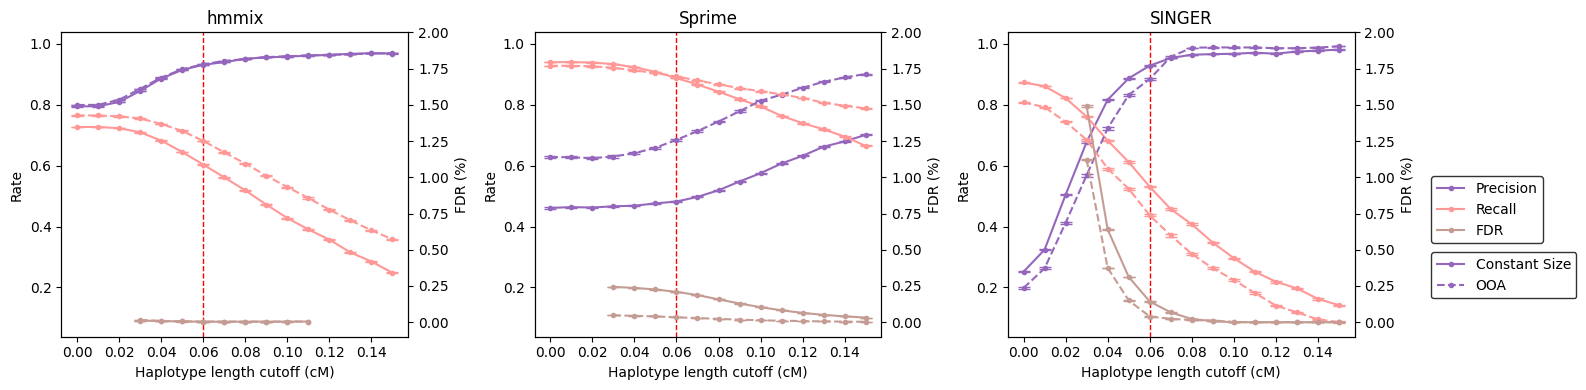

In [59]:
colors=mcp.gen_color(cmap="tab20",n=20)
cll = [colors[2], colors[4], colors[12], colors[8], colors[7]]
t = 15000 #[15000, 10000]
# 
# labels2=['0.02, 3600', '0.05, 3600', '0.1, 3600', '0.2, 3600', '0.02, 100', '0.02, 10000']
fig_utils = Figure_utils()
fig, ax = plt.subplots(1, 3, figsize=(16,4), sharey = 'all', sharex = 'all')
linestyles = ['-', '--', ':', '-.']
inference = ['hmmix', 'sprime', 'singer']
versions = ['m2_ori', 'm2_ori']#, 'm2_ori', 'intro_mha']
models = ['split_constant', 'ooa_neanderthal5r19_simp']#, 'ooa_neanderthal5r19_comp', 'ooa_neanderthal5r19_simp']
deme_label = ['Constant Size', 'OOA', 'Gene flow after OOA', 'Introgression before OOA']
# pps_label = ['True ARGs, Vanilla', 'True ARGs, OOA']#, 'True ARGs, Introgression before OOA', 'True ARGs, Gene flow after OOA'] 
# pps_label = pps_label + ['Relate, Vanilla', 'Relate, OOA']#, 'Relate, Introgression before OOA', 'Relate, Gene flow after OOA']
# pps_label = pps_label + ['SINGER, Vanilla', 'SINGER, OOA']#, 'SINGER, Introgression before OOA', 'SINGER, Gene flow after OOA']

for ii, f in enumerate(inference):
    ax2 = ax[ii].twinx()
    ax2.set_ylabel('FDR (%)')
    ax2.set_ylim([-0.1, 2])
    for j in range(len(versions)):
        if f == 'singer':
            fpath = '../results/hmm_results/arg_infer/'+str(models[j])+'/' + str(versions[j]) + '/' + str(f) + '/n' + str(n) + '_seed'
        else:
            fpath = '../results/hmm_results/inference_comparison/'+str(models[j])+'/' + str(versions[j]) + '/' + str(f) + '/n' + str(n) + '_seed'
        t_archaic = str(intro)
        df = Figure_utils().merge_seeds(filepath=fpath, t_admix=t, t_archaic=t_archaic, seeds=seeds)
        precision, precision_err = Figure_utils().get_datapoints(df=df, colname='precision', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
        recall, recall_err = Figure_utils().get_datapoints(df=df, colname='recall', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
        ax[ii].errorbar(l_cutoff, precision, yerr=precision_err,marker='o',markersize=3, color=colors[8],capsize=4, fmt = linestyles[j], label=f"{deme_label[j]}")
        ax[ii].errorbar(l_cutoff, recall, yerr=recall_err,marker='o',markersize=3, color=colors[7],capsize=4, fmt = linestyles[j])
        if f == "sprime":
            false_discovery, false_discovery_err = Figure_utils().get_datapoints(df=df, colname='false_discovery', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
            ax2.errorbar(l_cutoff[3:], false_discovery[3:] * (0.02 * 250) / 250, yerr=false_discovery_err[3:] * (0.02 * 250) / 250,marker='o',markersize=3, color=colors[11],capsize=4, fmt = linestyles[j])
        elif f == "hmmix":
            false_discovery, false_discovery_err = Figure_utils().get_datapoints(df=df, colname='fdc_length', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
            ax2.errorbar(l_cutoff[3:], false_discovery[3:] / 25, yerr=false_discovery_err[3:] / 25,marker='o',markersize=3, color=colors[11],capsize=4, fmt = linestyles[j])
        else:
            false_discovery, false_discovery_err = Figure_utils().get_datapoints(df=df, colname='false_discovery', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
            ax2.errorbar(l_cutoff[3:], false_discovery[3:] * 2, yerr=false_discovery_err[3:] * 2,marker='o',markersize=3, color=colors[11],capsize=4, fmt = linestyles[j])
    s = ax2.get_lines()
lines = ax[2].get_lines()
legend1 = ax[2].legend([lines[0], lines[3], s[0]], ['Precision','Recall','FDR'], bbox_to_anchor=(1.2, 0.55), loc='upper left')
frame1 = legend1.get_frame()
frame1.set_edgecolor('black')
legend2 = ax[2].legend([lines[i] for i in [0,6]], deme_label, bbox_to_anchor=(1.2, 0.3), loc='upper left')
frame2 = legend2.get_frame()
frame2.set_edgecolor('black')
ax[2].add_artist(legend1)

ax[0].axvline(x=0.06, color='red', linestyle='--', linewidth=1)
ax[1].axvline(x=0.06, color='red', linestyle='--', linewidth=1)
ax[2].axvline(x=0.06, color='red', linestyle='--', linewidth=1)
ax[0].set_xticks([0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14], ['0.00', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14'])
ax[1].set_xticks([0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14], ['0.00', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14'])
ax[2].set_xticks([0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14], ['0.00', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14'])
ax[0].yaxis.set_tick_params(labelleft=True)
ax[1].yaxis.set_tick_params(labelleft=True)
ax[2].yaxis.set_tick_params(labelleft=True)
ax[0].set_yticks([0.2, 0.4, 0.6, 0.8, 1], ['0.2', '0.4', '0.6', '0.8', '1.0'])
ax[1].set_yticks([0.2, 0.4, 0.6, 0.8, 1], ['0.2', '0.4', '0.6', '0.8', '1.0'])
ax[2].set_yticks([0.2, 0.4, 0.6, 0.8, 1], ['0.2', '0.4', '0.6', '0.8', '1.0'])
ax[0].set_ylabel('Rate')
ax[1].set_ylabel('Rate')
ax[2].set_ylabel('Rate')
ax[0].set_xlabel('Haplotype length cutoff (cM)')
ax[1].set_xlabel('Haplotype length cutoff (cM)')
ax[2].set_xlabel('Haplotype length cutoff (cM)')
ax[0].set_title('hmmix')
ax[1].set_title('Sprime')
ax[2].set_title('SINGER')
plt.tight_layout()
plt.savefig('../images/fig3def.pdf', bbox_inches='tight')


In [48]:
inference = "singer"
all_gammas = []
all_t1s = []
all_t2s = []
all_treelen = []
all_nleaves = []
treespan = []
for s in range(1, 6):
    gammas = []
    t1s = []
    t2s = []
    treelen = []
    nleaves = []
    if s == 1:
        for i in range(10):
            data = np.load(f"../results/hmm_results/arg_infer/ooa_neanderthal5r19_comp/m2_ori/{inference}/n100_seed{s}_15000_0.02_ppsind{i}.npz")
            all_gammas.append(data["n_gamma"][1])
            if len(data["at1s"].shape) == 2:
                all_t1s.append(np.median(data["at1s"], axis=0))
                all_t2s.append(np.median(data["at2s"], axis=0))
                all_nleaves.append(np.median(data["anleaves"], axis=0))
            else:
                all_t1s.append(data["at1s"])
                all_t2s.append(data["at2s"])
                all_nleaves.append(data["anleaves"])
            all_treelen.append(data["a_tree_span"][:, 1] - data["a_tree_span"][:, 0])
        all_gammas = np.array(all_gammas)
        all_t1s = np.array(all_t1s)
        all_t2s = np.array(all_t2s)
        all_treelen = np.array(all_treelen)
        treespan  = np.array(data["a_tree_span"])
    else:
        for i in range(10):
            data = np.load(f"../results/hmm_results/arg_infer/ooa_neanderthal5r19_comp/m2_ori/{inference}/n100_seed{s}_15000_0.02_ppsind{i}.npz")
            gammas.append(data["n_gamma"][1])
            if len(data["at1s"].shape) == 2:
                t1s.append(np.median(data["at1s"], axis=0))
                t2s.append(np.median(data["at2s"], axis=0))
                nleaves.append(np.median(data["anleaves"], axis=0))
            else:
                t1s.append(data["at1s"])
                t2s.append(data["at2s"])
                nleaves.append(data["anleaves"])
            treelen.append(data["a_tree_span"][:, 1] - data["a_tree_span"][:, 0])
        gammas = np.array(gammas)
        t1s = np.array(t1s)
        t2s = np.array(t2s)
        treelen = np.array(treelen)
        nleaves = np.array(nleaves)
        treespan = np.concatenate((treespan, data["a_tree_span"]), axis=0)
        all_gammas = np.concatenate((all_gammas, gammas), axis=1)
        all_t1s = np.concatenate((all_t1s, t1s), axis=1)
        all_t2s = np.concatenate((all_t2s, t2s), axis=1)
        all_nleaves = np.concatenate((all_nleaves, nleaves), axis=1)
        all_treelen = np.concatenate((all_treelen, treelen), axis=1)

In [49]:
inference = "SINGER"
l_cutoff = [0.02, 0.03, 0.05, 0.07, 0.09, 0.11]
data_dict = {"l_cutoff":[], "t1s":[], "t2s_single":[], "t2s_mean":[], "t1s_q2.5":[], "t1s_q97.5":[], "t2s_single_q2.5":[], "t2s_single_q97.5":[], "t2s_mean_q2.5":[], "t2s_mean_q97.5":[], "inference":[]}
for l in l_cutoff:
    inferred, states = Performance_utils().filter_hmm_output(arc_cutoff=0.5,
        pp_cutoff=0.9,
        l_cutoff=l,
        popmerge=False,
        maxlen=None,
        combined_pp=all_gammas,
        treespan=treespan,
    )
    t_states = states[states > 0]
    t1s = all_t1s[states > 0]
    t2s = all_t2s[states > 0]
    nleaves = all_nleaves[states > 0]
    s_t1s = []
    sm_t2s = []
    s_t2s = []
    for ustate in np.unique(t_states):
        s_t1s.append(np.median(t1s[t_states == ustate]))
        sm_t2s.append(np.median(t2s[t_states == ustate]))
        subnl = nleaves[t_states == ustate]
        subt2s = t2s[t_states == ustate]
        s_t2s.append(np.median(subt2s[subnl < 2]))
    s_t1s = np.array(s_t1s)
    s_t1s = s_t1s[~np.isnan(s_t1s)]
    s_t2s = np.array(s_t2s)
    s_t2s = s_t2s[~np.isnan(s_t2s)]
    sm_t2s = np.array(sm_t2s)
    sm_t2s = sm_t2s[~np.isnan(sm_t2s)]
    print(len(nleaves[nleaves < 2]))
    print(len(s_t1s), len(s_t2s), len(sm_t2s))
    data_dict["l_cutoff"].append(l)
    if len(s_t1s) > 0:
        data_dict["t1s"].append(np.mean(s_t1s))
        data_dict["t1s_q2.5"].append(np.percentile(s_t1s, 2.5))
        data_dict["t1s_q97.5"].append(np.percentile(s_t1s, 97.5))
    else:
        data_dict["t1s"].append(np.nan)
        data_dict["t1s_q2.5"].append(np.nan)
        data_dict["t1s_q97.5"].append(np.nan)
    if len(s_t2s) > 0:        
        data_dict["t2s_single"].append(np.mean(s_t2s))
        data_dict["t2s_single_q2.5"].append(np.percentile(s_t2s, 2.5))
        data_dict["t2s_single_q97.5"].append(np.percentile(s_t2s, 97.5))
    else:
        data_dict["t2s_single"].append(np.nan)
        data_dict["t2s_single_q2.5"].append(np.nan)
        data_dict["t2s_single_q97.5"].append(np.nan)
    if len(sm_t2s) > 0:
        data_dict["t2s_mean"].append(np.mean(sm_t2s))
        data_dict["t2s_mean_q2.5"].append(np.percentile(sm_t2s, 2.5))
        data_dict["t2s_mean_q97.5"].append(np.percentile(sm_t2s, 97.5))
    else:
        data_dict["t2s_mean"].append(np.nan)
        data_dict["t2s_mean_q2.5"].append(np.nan)
        data_dict["t2s_mean_q97.5"].append(np.nan)
    data_dict["inference"].append(inference)
dff = pd.DataFrame.from_dict(data_dict)
if inference == 'True ARGs':
    df = pd.DataFrame()
df = pd.concat([df, dff], axis=0)

8
2185 4 2185
3
782 2 782
1
149 1 149
0
84 0 84
0
51 0 51
0
34 0 34


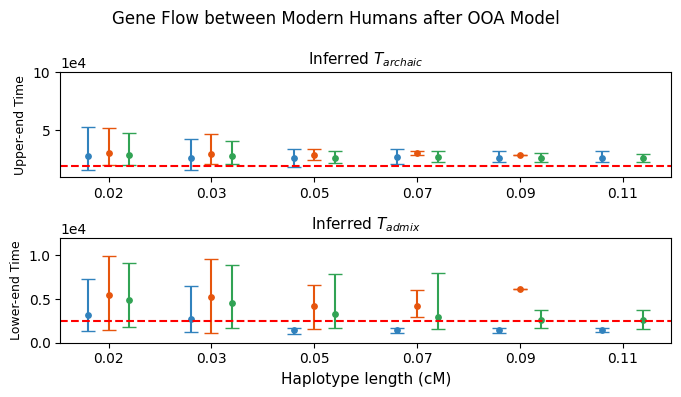

In [50]:
fig, ax = plt.subplots(2, 1, figsize = (7, 4))
colors=mcp.gen_color(cmap="tab20c",n=20)

dff = df[df['inference'] == 'True ARGs']
lower = dff["t2s_mean"] - dff["t2s_mean_q2.5"]
upper = dff["t2s_mean_q97.5"] - dff["t2s_mean"]
# lower[lower < 0] = 0
# upper[upper < 0] = 0
ayerr = np.vstack([lower, upper])
ax[0].errorbar(np.array(range(6)) - 0.2, dff["t2s_mean"], yerr=ayerr, marker = 'o', markerfacecolor='none', markersize=0, color=colors[0],capsize=5, fmt = 'none')
ax[0].scatter(np.array(range(6)) - 0.2, dff["t2s_mean"], s =15, color = colors[0], label='True ARGs')
# lower = dff["t2s_single"] - dff["t2s_single_q2.5"]
# upper = dff["t2s_single_q97.5"] - dff["t2s_single"]
# # lower[lower < 0] = 0
# # upper[upper < 0] = 0
# ayerr = np.vstack([lower, upper])
# ax[1].errorbar(np.array(range(6)) - 0.2, dff["t2s_single"], yerr=ayerr, marker = 'o', markerfacecolor='none', markersize=0, color=colors[0],capsize=5, fmt = 'none')
# ax[1].scatter(np.array(range(6)) - 0.2, dff["t2s_single"], s =15, color = colors[0], label='True ARGs')
lower = dff["t1s"] - dff["t1s_q2.5"]
upper = dff["t1s_q97.5"] - dff["t1s"]
# lower[lower < 0] = 0
# upper[upper < 0] = 0
ayerr = np.vstack([lower, upper])
ax[1].errorbar(np.array(range(6)) - 0.2, dff["t1s"], yerr=ayerr, marker = 'o', markerfacecolor='none', markersize=0, color=colors[0],capsize=5, fmt = 'none')
ax[1].scatter(np.array(range(6)) - 0.2, dff["t1s"], s =15, color = colors[0], label='True ARGs')

dff = df[df['inference'] == 'Relate']
lower = dff["t2s_mean"] - dff["t2s_mean_q2.5"]
upper = dff["t2s_mean_q97.5"] - dff["t2s_mean"]
# lower[lower < 0] = 0
# upper[upper < 0] = 0
ayerr = np.vstack([lower, upper])
ax[0].errorbar(np.array(range(6)), dff["t2s_mean"], yerr=ayerr, marker = 'o', markerfacecolor='none', markersize=0, color=colors[4],capsize=5, fmt = 'none')
ax[0].scatter(np.array(range(6)), dff["t2s_mean"], s =15, color = colors[4], label='Relate')
# lower = dff["t2s_single"] - dff["t2s_single_q2.5"]
# upper = dff["t2s_single_q97.5"] - dff["t2s_single"]
# # lower[lower < 0] = 0
# # upper[upper < 0] = 0
# ayerr = np.vstack([lower, upper])
# ax[1].errorbar(np.array(range(6)), dff["t2s_single"], yerr=ayerr, marker = 'o', markerfacecolor='none', markersize=0, color=colors[4],capsize=5, fmt = 'none')
# ax[1].scatter(np.array(range(6)), dff["t2s_single"], s =15, color = colors[4], label='Relate')
lower = dff["t1s"] - dff["t1s_q2.5"]
upper = dff["t1s_q97.5"] - dff["t1s"]
# lower[lower < 0] = 0
# upper[upper < 0] = 0
ayerr = np.vstack([lower, upper])
ax[1].errorbar(np.array(range(6)), dff["t1s"], yerr=ayerr, marker = 'o', markerfacecolor='none', markersize=0, color=colors[4],capsize=5, fmt = 'none')
ax[1].scatter(np.array(range(6)), dff["t1s"], s =15, color = colors[4], label='Relate')

dff = df[df['inference'] == 'SINGER']
lower = dff["t2s_mean"] - dff["t2s_mean_q2.5"]
upper = dff["t2s_mean_q97.5"] - dff["t2s_mean"]
# lower[lower < 0] = 0
# upper[upper < 0] = 0
ayerr = np.vstack([lower, upper])
ax[0].errorbar(np.array(range(6)) + 0.2, dff["t2s_mean"], yerr=ayerr, marker = 'o', markerfacecolor='none', markersize=0, color=colors[8],capsize=5, fmt = 'none')
ax[0].scatter(np.array(range(6)) + 0.2, dff["t2s_mean"], s =15, color = colors[8], label='SINGER')
# lower = dff["t2s_single"] - dff["t2s_single_q2.5"]
# upper = dff["t2s_single_q97.5"] - dff["t2s_single"]
# # lower[lower < 0] = 0
# # upper[upper < 0] = 0
# ayerr = np.vstack([lower, upper])
# ax[1].errorbar(np.array(range(6)) + 0.2, dff["t2s_single"], yerr=ayerr, marker = 'o', markerfacecolor='none', markersize=0, color=colors[8],capsize=5, fmt = 'none')
# ax[1].scatter(np.array(range(6)) + 0.2, dff["t2s_single"], s =15, color = colors[8], label='SINGER')
lower = dff["t1s"] - dff["t1s_q2.5"]
upper = dff["t1s_q97.5"] - dff["t1s"]
# lower[lower < 0] = 0
# upper[upper < 0] = 0
ayerr = np.vstack([lower, upper])
ax[1].errorbar(np.array(range(6)) + 0.2, dff["t1s"], yerr=ayerr, marker = 'o', markerfacecolor='none', markersize=0, color=colors[8],capsize=5, fmt = 'none')
ax[1].scatter(np.array(range(6)) + 0.2, dff["t1s"], s =15, color = colors[8], label='SINGER')


formatter = ScalarFormatter()#useMathText=True)
formatter.set_powerlimits((4, 4))  # Force 1e4 notation
ax[0].yaxis.set_major_formatter(formatter)
formatter = ScalarFormatter()#useMathText=True)
formatter.set_powerlimits((4, 4))  # Force 1e4 notation
ax[1].yaxis.set_major_formatter(formatter)
# formatter1 = ScalarFormatter()#useMathText=True)
# formatter1.set_powerlimits((3, 3))  # Force 1e4 notation
# ax[2].yaxis.set_major_formatter(formatter1)
ax[0].axhline(y=19275, color='red', linestyle='--')
ax[0].set_ylabel('Upper-end Time', fontsize=9)
# ax[1].axhline(y=19275, color='red', linestyle='--')
# ax[1].set_ylabel('Upper-end Time', fontsize=9)
ax[1].axhline(y=2500, color='red', linestyle='--')
ax[1].set_ylabel('Lower-end Time', fontsize=9)
# ax[0].set_yscale('log')
ax[0].set_ylim([1e4, 10e4])
# ax[1].set_ylim([1e4, 10e4])
ax[1].set_ylim([0, 12e3])
ax[1].set_xlabel('Haplotype length (cM)', fontsize=11)
ax[0].set_xticks(range(6))
ax[1].set_xticks(range(6))
# ax[2].set_xticks(range(6))
ax[0].set_xticklabels(df['l_cutoff'].unique())
ax[1].set_xticklabels(df['l_cutoff'].unique())
# ax[2].set_xticklabels(df['l_cutoff'].unique())
# ax[1].set_title(r'Inferred $T_{archaic}$: mean over single-leaf branches', fontsize=11)
ax[0].set_title(r'Inferred $T_{archaic}$', fontsize=11)
ax[1].set_title(r'Inferred $T_{admix}$', fontsize=11)
fig.suptitle('Gene Flow between Modern Humans after OOA Model', fontsize=12)
# legend2 = ax[1].legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)
# frame2 = legend2.get_frame()
# frame2.set_edgecolor('black')
plt.tight_layout()
plt.savefig('../images/figS3_2c.pdf', bbox_inches='tight')


/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:929: RuntimeWarning: Mean of empty slice
  out.append(np.nanmean(pres))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zh

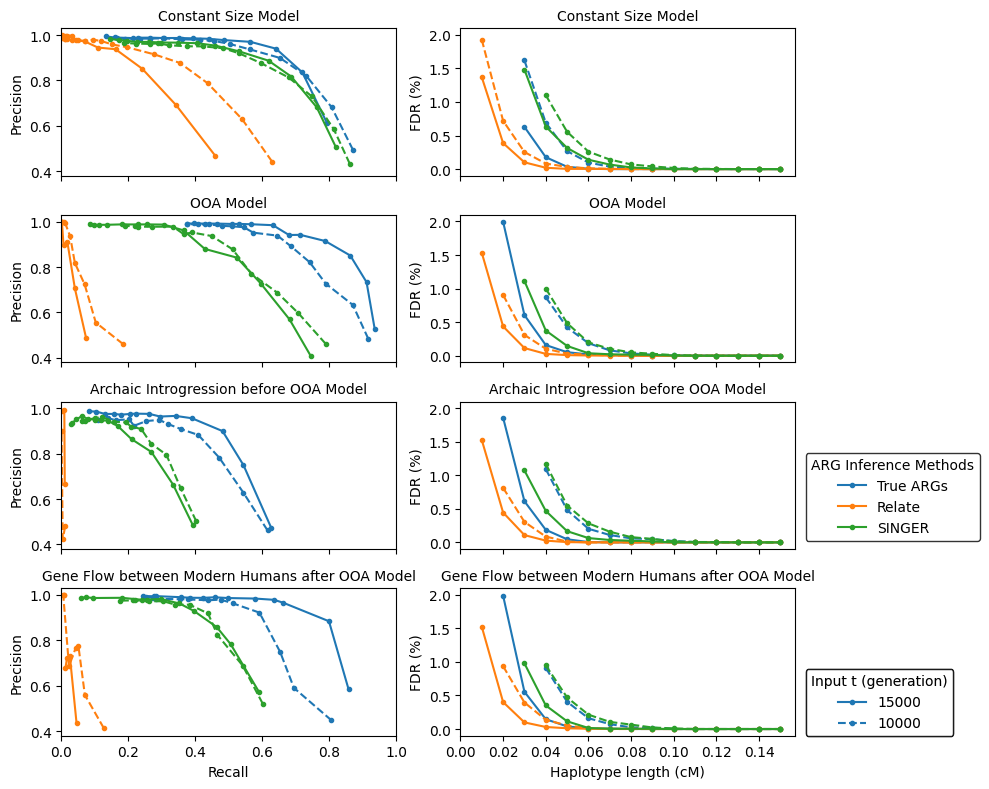

In [5]:
conf = yaml.safe_load(Path('../config/analysis.config.yaml').read_text())
s1 = range(1, 11)
s2 = [1, 2, 3, 4, 5]
n = conf['arg_infer']['n']
pp_cutoff = conf['pp_cutoff']
l_cutoff = np.array(conf['l_cutoff'])
linestyles = ['-', '--', ':', '-.']
inference = ['msprime', 'relate', 'singer']
intro = conf['arg_infer']['models']['split_constant']['intro'][0]
t = [15000, 10000]

versions = ['m2_ori', 'm2_ori', 'intro_mha', 'm2_ori']
models = ['split_constant', 'ooa_neanderthal5r19_simp', 'ooa_neanderthal5r19_simp', 'ooa_neanderthal5r19_comp']
methods = ["True ARGs", "Relate", "SINGER"]
model_labels = ["Constant Size Model", "OOA Model", "Archaic Introgression before OOA Model", "Gene Flow between Modern Humans after OOA Model"]
markers = ['D', 'o', '^']
pps = [0.9, 0.9, 0.9]
colors=mcp.gen_color(cmap="tab10",n=10)
fig, ax = plt.subplots(4, 2, figsize=(10,8), sharey = 'col', sharex = 'col')
for j in range(len(versions)):
    for f in range(len(inference)):
        for tidx, tt in enumerate(t):
            fpath = '../results/hmm_results/arg_infer/'+str(models[j])+'/' + str(versions[j]) + '/' +str(inference[f]) + '/n' + str(n) + '_seed'
            t_archaic = str(intro)
            if versions[j] == 'intro_mha' or models[j] == 'ooa_neanderthal5r19_comp':
                seeds = s2
            else:
                seeds = s1
            df = Figure_utils().merge_seeds(filepath=fpath, t_admix=tt, t_archaic=t_archaic, seeds=seeds)
            precision, precision_err = Figure_utils().get_datapoints(df=df, colname='precision', ntime=30, pp_cutoff=pps[f], l_cutoff=l_cutoff)
            recall, recall_err = Figure_utils().get_datapoints(df=df, colname='recall', ntime=30, pp_cutoff=pps[f], l_cutoff=l_cutoff)
            false_discovery, false_discovery_err = Figure_utils().get_datapoints(df=df, colname='false_discovery', ntime=30, pp_cutoff=pps[f], l_cutoff=l_cutoff)
            ax[j][0].plot(recall[precision > 0.4], precision[precision > 0.4], marker=markers[1], markersize=3, color=colors[f], label=methods[f], linestyle=linestyles[tidx])
            ax[j][1].plot(l_cutoff[false_discovery < 1], false_discovery[false_discovery < 1] *2, marker=markers[1], markersize=3, color=colors[f], label=methods[f], linestyle=linestyles[tidx])
    ax[j][0].set_ylabel('Precision')
    ax[j][0].set_title(model_labels[j], fontsize=10)
    ax[j][1].set_ylabel('FDR (%)')
    ax[j][1].set_title(model_labels[j], fontsize=10)
lines = ax[3][1].get_lines()
legend1 = ax[3][1].legend([lines[i] for i in [0, 1]], ['15000', '10000'], bbox_to_anchor=(1.01, 0.5), loc='upper left', title='Input t (generation)')
frame1 = legend1.get_frame()
frame1.set_edgecolor('black')
legend2 = ax[2][1].legend([lines[i] for i in [0, 2, 4]], methods, bbox_to_anchor=(1.01, 0.7), loc='upper left', title='ARG Inference Methods')
frame2 = legend2.get_frame()
frame2.set_edgecolor('black')
ax[3][1].add_artist(legend1)

ax[0][0].set_xlim([0, 1])
# formatter = ScalarFormatter()#useMathText=True)
# formatter.set_powerlimits((-2, -2))  # Force 1e4 notation
# ax[0][1].yaxis.set_major_formatter(formatter)
# ax[1][1].yaxis.set_major_formatter(formatter)
# ax[2][1].yaxis.set_major_formatter(formatter)
# ax[3][1].yaxis.set_major_formatter(formatter)
ax[0][1].set_xticks([0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14], ['0.00', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14'])
ax[3][0].set_xlabel('Recall')
ax[3][1].set_xlabel('Haplotype length (cM)')
plt.tight_layout()
plt.savefig('../images/figS3_1.pdf', bbox_inches='tight')

/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:929: RuntimeWarning: Mean of empty slice
  out.append(np.nanmean(pres))
/global/scratch/users/zhangyulin9806/github/ghost_admixture_hmm/notebooks/../arg_hmm/utils.py:876: RuntimeWarning: Mean of empty slice
  out.append(func(sample))
/global/scratch/users/zh

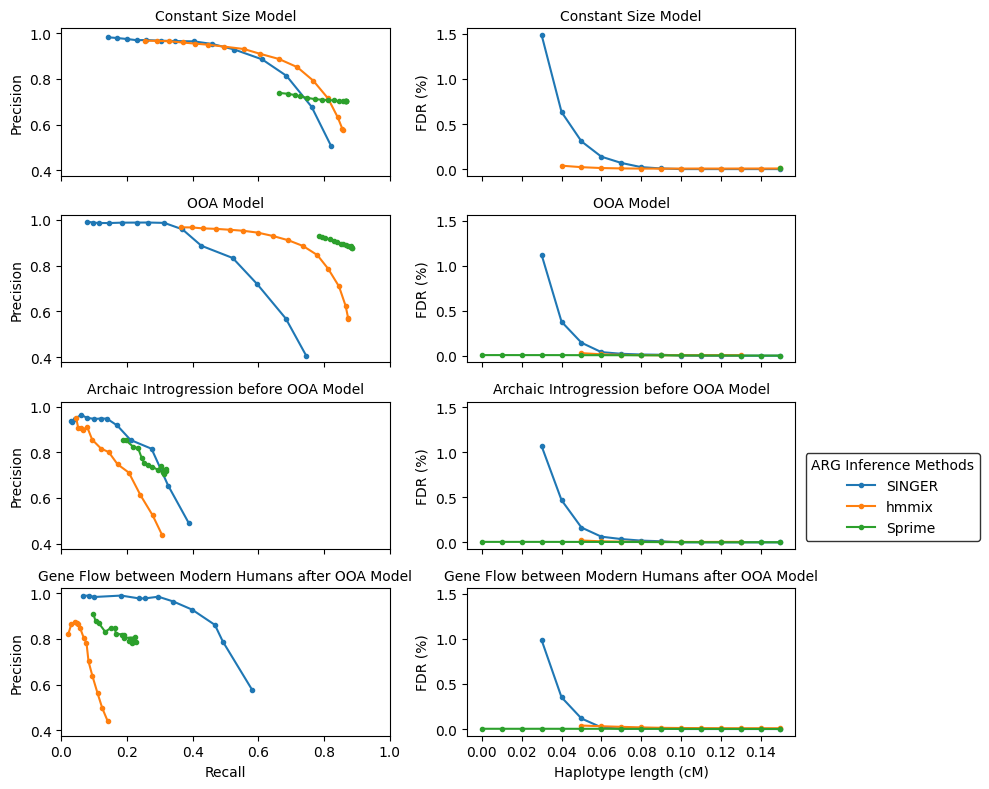

In [66]:
conf = yaml.safe_load(Path('../config/analysis.config.yaml').read_text())
s1 = range(1, 11)
s2 = [1, 2, 3, 4, 5]
n = conf['arg_infer']['n']
pp_cutoff = conf['pp_cutoff']
l_cutoff = np.array(conf['l_cutoff'])
linestyles = ['-', '--', ':', '-.']
inference = ['singer','hmmix', 'sprime']
intro = conf['arg_infer']['models']['split_constant']['intro'][0]
t = [15000]

versions = ['m2_ori', 'm2_ori', 'intro_mha', 'm2_ori']
models = ['split_constant', 'ooa_neanderthal5r19_simp', 'ooa_neanderthal5r19_simp', 'ooa_neanderthal5r19_comp']
methods = ["SINGER","hmmix", "Sprime"]
model_labels = ["Constant Size Model", "OOA Model", "Archaic Introgression before OOA Model", "Gene Flow between Modern Humans after OOA Model"]
markers = ['D', 'o', '^']
pps = [0.9, 0.8, 0.95]
colors=mcp.gen_color(cmap="tab10",n=10)
fig, ax = plt.subplots(4, 2, figsize=(10,8), sharey = 'col', sharex = 'col')
for j in range(len(versions)):
    for f in range(len(inference)):
        for tidx, tt in enumerate(t):
            if inference[f] == 'singer':
                fpath = '../results/hmm_results/arg_infer/'+str(models[j])+'/' + str(versions[j]) + '/' +str(inference[f]) + '/n' + str(n) + '_seed'
            else:
                fpath = '../results/hmm_results/inference_comparison/'+str(models[j])+'/' + str(versions[j]) + '/' + str(inference[f]) + '/n' + str(n) + '_seed'
            t_archaic = str(intro)
            if versions[j] == 'intro_mha' or models[j] == 'ooa_neanderthal5r19_comp':
                seeds = s2
            else:
                seeds = s1
            df = Figure_utils().merge_seeds(filepath=fpath, t_admix=tt, t_archaic=t_archaic, seeds=seeds)
            precision, precision_err = Figure_utils().get_datapoints(df=df, colname='precision', ntime=30, pp_cutoff=pps[f], l_cutoff=l_cutoff)
            recall, recall_err = Figure_utils().get_datapoints(df=df, colname='recall', ntime=30, pp_cutoff=pps[f], l_cutoff=l_cutoff)
            if inference[f] == 'hmmix':
                false_discovery, false_discovery_err = Figure_utils().get_datapoints(df=df, colname='fdc_length', ntime=30, pp_cutoff=pps[f], l_cutoff=l_cutoff)
            else:
                false_discovery, false_discovery_err = Figure_utils().get_datapoints(df=df, colname='false_discovery', ntime=30, pp_cutoff=pps[f], l_cutoff=l_cutoff)
            ax[j][0].plot(recall[precision > 0.4], precision[precision > 0.4], marker=markers[1], markersize=3, color=colors[f], label=methods[f], linestyle=linestyles[tidx])
            if inference[f] == 'hmmix':
                ax[j][1].plot(l_cutoff[false_discovery < 1], false_discovery[false_discovery < 1] / 25, marker=markers[1], markersize=3, color=colors[f], label=methods[f], linestyle=linestyles[tidx])
            elif inference[f] == 'sprime':
                ax[j][1].plot(l_cutoff[false_discovery < 1], false_discovery[false_discovery < 1] * (0.02 * 250) / 250, marker=markers[1], markersize=3, color=colors[f], label=methods[f], linestyle=linestyles[tidx])
            else:
                ax[j][1].plot(l_cutoff[false_discovery < 1], false_discovery[false_discovery < 1] *2, marker=markers[1], markersize=3, color=colors[f], label=methods[f], linestyle=linestyles[tidx])
    ax[j][0].set_ylabel('Precision')
    ax[j][0].set_title(model_labels[j], fontsize=10)
    ax[j][1].set_ylabel('FDR (%)')
    ax[j][1].set_title(model_labels[j], fontsize=10)
lines = ax[2][1].get_lines()
# legend1 = ax[3][1].legend([lines[i] for i in [0, 1]], ['15000', '10000'], bbox_to_anchor=(1.01, 0.5), loc='upper left', title='Input t (generation)')
# frame1 = legend1.get_frame()
# frame1.set_edgecolor('black')
legend2 = ax[2][1].legend([lines[i] for i in [0, 1, 2]], methods, bbox_to_anchor=(1.01, 0.7), loc='upper left', title='ARG Inference Methods')
frame2 = legend2.get_frame()
frame2.set_edgecolor('black')
# ax[3][1].add_artist(legend1)

ax[0][0].set_xlim([0, 1])
# formatter = ScalarFormatter()#useMathText=True)
# formatter.set_powerlimits((-2, -2))  # Force 1e4 notation
# ax[0][1].yaxis.set_major_formatter(formatter)
# ax[1][1].yaxis.set_major_formatter(formatter)
# ax[2][1].yaxis.set_major_formatter(formatter)
# ax[3][1].yaxis.set_major_formatter(formatter)
ax[0][1].set_xticks([0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14], ['0.00', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14'])
ax[3][0].set_xlabel('Recall')
ax[3][1].set_xlabel('Haplotype length (cM)')
plt.tight_layout()
plt.savefig('../images/figS3_1_v2.pdf', bbox_inches='tight')

In [37]:
# data = np.load("../results/hmm_results/arg_infer/split_constant/m2_ori/msprime/n100_seed1_15000_0.02_ppsind0.npz")
# t1s = data["at1s"]
# t2s = data["at2s"]
# ncoal = data["ancoal"]
# treespan = data["a_tree_span"]
# data = np.load("../results/hmm_results/arg_infer/split_constant/m2_ori/relate/n100_seed1_15000_0.02_ppsind0.npz")
# t1s = data["at1s"]
# t2s = data["at2s"]
# ncoal = data["ancoal"]
# treespan = data["a_tree_span"]
data = np.load("../results/hmm_results/arg_infer/split_constant/m2_ori/singer/n100_seed1_15000_0.02_ppsind0.npz")
t1s = np.median(data["at1s"], axis=0)
t2s = np.median(data["at2s"], axis=0)
ncoal = np.mean(data["ancoal"], axis=0)
treespan = data["a_tree_span"]
idx = 0
truth = Performance_utils().read_truth_bed("../results/simulations/outputs/split_constant/m2_ori/n100_seed1.indiv.bed", 200)
didx = []
for x in truth[idx]:
    [x1,x2] = x
    for i in range(treespan.shape[0]):
        [y1,y2] = treespan[i]
        if (max(x1,y1) < min(x2,y2)):
            didx.append(i)
n_idx = [i for i in range(treespan.shape[0]) if i not in didx]

KS Statistic: 0.7539638174515313, P-value: 0.0


/global/scratch/users/zhangyulin9806/tmp/ipykernel_432424/3301182019.py:14: RuntimeWarning: divide by zero encountered in divide
  dff_vec = ncoal / (t2s - t1s)


KS Statistic: 0.7917833926501212, P-value: 0.0
KS Statistic: 0.41377663807438503, P-value: 5.06893438160452e-296


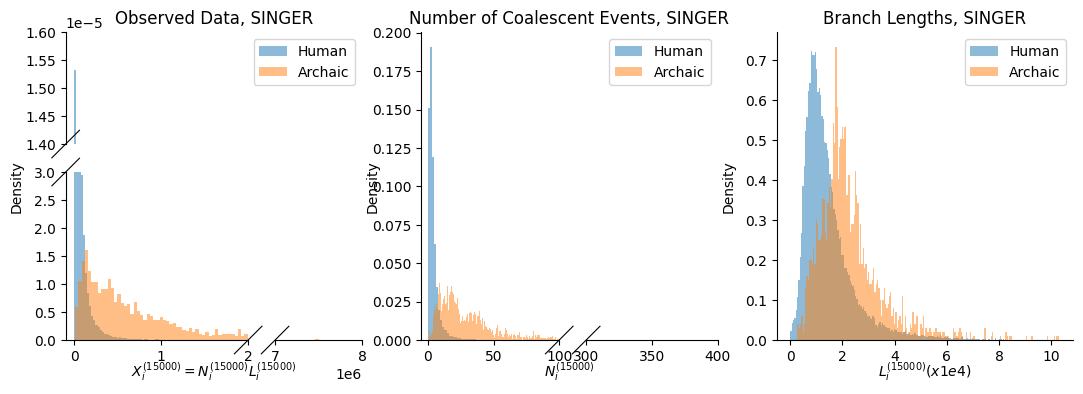

In [39]:
dff_vec = ncoal
fig = plt.figure(figsize=(13, 4))
sps1, sps2, sps3 = GridSpec(1,3)
bax = brokenaxes(xlims=((-1e5, 2e6), (7e6, 8e6)), ylims = ((0, 0.3e-5), (1.4e-5, 1.6e-5)),subplot_spec=sps1)
bax.hist(dff_vec[n_idx], bins=200, label='Human', alpha = 0.5, density=True)
bax.hist(dff_vec[didx], bins=200, label='Archaic', alpha = 0.5, density=True)
# bax.set_yticks([0, 0.1e-5, 0.2e-5, 0.3e-5, 0.4e-5, 0.5e-5, 0.6e-5], ['0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6'])
bax.set_xlabel(r"$X_{i}^{(15000)} = N_{i}^{(15000)}L_{i}^{(15000)}$")
bax.set_ylabel('Density')
bax.set_title('Observed Data, SINGER')
bax.legend()
ks_stat, p_value = ks_2samp(dff_vec[n_idx], dff_vec[didx])
print(f"KS Statistic: {ks_stat}, P-value: {p_value}")
dff_vec = ncoal / (t2s - t1s)
dff_vec[dff_vec == np.inf] = 0
bax = brokenaxes(xlims=((-5, 100), (300, 400)),subplot_spec=sps2)
bax.hist(dff_vec[n_idx], bins=200, label='Human', alpha = 0.5, density=True)
bax.hist(dff_vec[didx], bins=200, label='Archaic', alpha = 0.5, density=True)
bax.set_xlabel(r"$N_{i}^{(15000)}$")
bax.set_ylabel('Density')
bax.set_title('Number of Coalescent Events, SINGER')
bax.legend()
ks_stat, p_value = ks_2samp(dff_vec[n_idx], dff_vec[didx])
print(f"KS Statistic: {ks_stat}, P-value: {p_value}")
dff_vec = (t2s - t1s) / 1e4
dff_vec[dff_vec == np.inf] = 0
bax = brokenaxes(subplot_spec=sps3) #xlims=((-2.5, 15), (30, 35)), 
bax.hist(dff_vec[n_idx], bins=200, label='Human', alpha = 0.5, density=True)
bax.hist(dff_vec[didx], bins=200, label='Archaic', alpha = 0.5, density=True)
bax.set_xlabel(r"$L_{i}^{(15000)} (x 1e4)$")
bax.set_ylabel('Density')
bax.set_title('Branch Lengths, SINGER')
bax.legend()
ks_stat, p_value = ks_2samp(dff_vec[n_idx], dff_vec[didx])
print(f"KS Statistic: {ks_stat}, P-value: {p_value}")
plt.savefig('../images/figS3_2ghi.pdf')

In [37]:
def summarize_window(treespan, windowsize, tncoal, tt1s, tt2s):
    genome_length = treespan[-1][1]
    m = int(genome_length / windowsize) + int(genome_length % windowsize > 0)
    ncoal_sub = np.zeros(m)
    t1s_sub = np.zeros(m)
    t2s_sub = np.zeros(m)
    t = 0
    curtrees = []
    for k in range(m):
        while t < treespan.shape[0] and treespan[t][0] < int(k * windowsize + windowsize):
            curtrees.append(t)
            t += 1
        if len(curtrees) == 0:
            ncoal_sub[k] = tncoal[t - 1]
            t1s_sub[k] = tt1s[t - 1]
            t2s_sub[k] = tt2s[t - 1]
        else:
            treelens = []
            curtrees = np.array(curtrees)
            curtrees = curtrees[curtrees >= 0]
            if len(curtrees) == 0:
                accessible_windows[k] = 0
                if k == 0:
                    ncoal_sub[k] = 1e-10
                    t1s_sub[k] = 0
                    t2s_sub[k] = 0
                else:
                    ncoal_sub[k] = ncoal_sub[k - 1]
                    t1s_sub[k] = t1s_sub[k - 1]
                    t2s_sub[k] = t1s_sub[k - 1]
            else:
                for j in range(len(curtrees)):
                    treelens.append(min(treespan[curtrees[j]][1], int(k * windowsize + windowsize)) - max(treespan[curtrees[j]][0], int(k * windowsize)))
                treelens = np.array(treelens)
                curtrees = curtrees[treelens > 1]
                treelens = treelens[treelens > 1]
                if len(curtrees) == 0:
                    ncoal_sub[k] = tncoal[t - 1]
                    t1s_sub[k] = tt1s[t - 1]
                    t2s_sub[k] = tt2s[t - 1]
                else:
                    ncoal_sub[k] = np.average(tncoal[curtrees], weights=treelens)
                    t1s_sub[k] = np.average(tt1s[curtrees], weights=treelens)
                    t2s_sub[k] = np.average(tt2s[curtrees], weights=treelens)
            curtrees = []
            if treespan[t-1][1] < (k+1) * windowsize + windowsize:
                curtrees.append(t - 1)
    return ncoal_sub, t1s_sub, t2s_sub

In [38]:
data_true = np.load("../results/hmm_results/arg_infer/split_constant/m2_ori/msprime/n100_seed1_15000_0.02_ppsind0.npz")
t1s_sub = data_true["at1s"]
t2s_sub = data_true["at2s"]
ncoal_sub = data_true["ancoal"]
treespan_true = data_true["a_tree_span"] * 1e6
ncoal_true, t1s_true, t2s_true = summarize_window(treespan_true, 1000, ncoal_sub, t1s_sub, t2s_sub)
data_relate = np.load("../results/hmm_results/arg_infer/split_constant/m2_ori/relate/n100_seed1_15000_0.02_ppsind0.npz")
t1s_relate = data_relate["at1s"]
t2s_relate = data_relate["at2s"]
ncoal_relate = data_relate["ancoal"]
treespan_relate = data_relate["a_tree_span"] * 1e6
ncoal_relate, t1s_relate, t2s_relate = summarize_window(treespan_relate, 1000, ncoal_relate, t1s_relate, t2s_relate)
data_singer = np.load("../results/hmm_results/arg_infer/split_constant/m2_ori/singer/n100_seed1_15000_0.02_ppsind0.npz")
t1s_singer = np.median(data_singer["at1s"], axis=0)
t2s_singer = np.median(data_singer["at2s"], axis=0)
ncoal_singer = np.mean(data_singer["ancoal"], axis=0)
treespan = data_singer["a_tree_span"]
idx = 0
truth = Performance_utils().read_truth_bed("../results/simulations/outputs/split_constant/m2_ori/n100_seed1.indiv.bed", 200)
didx = []
for x in truth[idx]:
    [x1,x2] = x
    for i in range(treespan.shape[0]):
        [y1,y2] = treespan[i]
        if (max(x1,y1) < min(x2,y2)):
            didx.append(i)
n_idx = [i for i in range(treespan.shape[0]) if i not in didx]

In [39]:
true = t1s_true[didx].tolist() + t2s_true[didx].tolist()
relate = t1s_relate[didx].tolist() + t2s_relate[didx].tolist()
singer = t1s_singer[didx].tolist() + t2s_singer[didx].tolist()
tlabel = ["Lower-end"] * len(didx) + ["Upper-end"] * len(didx)
data = {"True ARGs": true, "Relate":relate, "SINGER":singer, "Times":tlabel}
df = pd.DataFrame.from_dict(data)

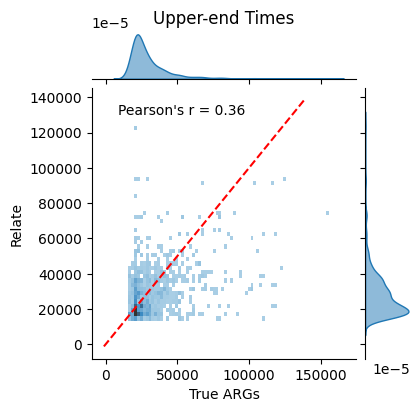

In [43]:
cls = sns.color_palette("tab10").as_hex()
g = sns.JointGrid(
    data=df[df['Times'] == 'Upper-end'],
    x="True ARGs", 
    y="Relate",
    height=4
)
g.plot_joint(sns.histplot, cmap="Blues_d")
g.plot_marginals(sns.kdeplot, fill=True, alpha=0.5, color=cls[0])
g.ax_marg_x.set_title('Upper-end Times')
# correlation
corr = pearsonr(df[df['Times'] == 'Upper-end']['True ARGs'], df[df['Times'] == 'Upper-end']['Relate'])[0]
g.ax_joint.text(0.1, 0.9, f"Pearson's r = {corr:.2f}", transform=g.ax_joint.transAxes)
# g.ax_joint.set_yscale('log')
# g.ax_marg_y.set_yscale('log')
# g.ax_joint.set_xscale('log')
# g.ax_marg_x.set_xscale('log')
x_min, x_max = g.ax_joint.get_xlim()
y_min, y_max = g.ax_joint.get_ylim()
lims = [
    np.max([x_min, y_min]),
    np.min([x_max, y_max]),
]
g.ax_joint.plot(lims, lims, '--r')
plt.savefig('../images/figS3_4d.pdf', bbox_inches='tight')

In [27]:
idx = 0
true = np.load('../results/tmrca/split_constant/m2_ori/n100_seed1_truth.npz')
true_tmrca = true['tmrca'][true['inds'] == idx]
relate = np.load('../results/tmrca/split_constant/m2_ori/n100_seed1_relate.npz')
relate_tmrca = relate['tmrca'][relate['inds'] == idx]
for i in range(150, 200):
    singer = np.load(f'../results/tmrca/split_constant/m2_ori/n100_seed1_singer_{i}.npz')
    if i == 150:
        singer_tmrca = singer['tmrca'][singer['inds'] == idx]
    else:
        singer_tmrca += singer['tmrca'][singer['inds'] == idx]
singer_tmrca = singer_tmrca / 50
data_singer = np.load("../results/hmm_results/arg_infer/split_constant/m2_ori/singer/n100_seed1_15000_0.02_ppsind0.npz")
treespan = data_singer["a_tree_span"]
truth = Performance_utils().read_truth_bed("../results/simulations/outputs/split_constant/m2_ori/n100_seed1.indiv.bed", 200)
didx = []
for x in truth[idx]:
    [x1,x2] = x
    for i in range(treespan.shape[0]):
        [y1,y2] = treespan[i]
        if (max(x1,y1) < min(x2,y2)):
            didx.append(i)
n_idx = [i for i in range(treespan.shape[0]) if i not in didx]

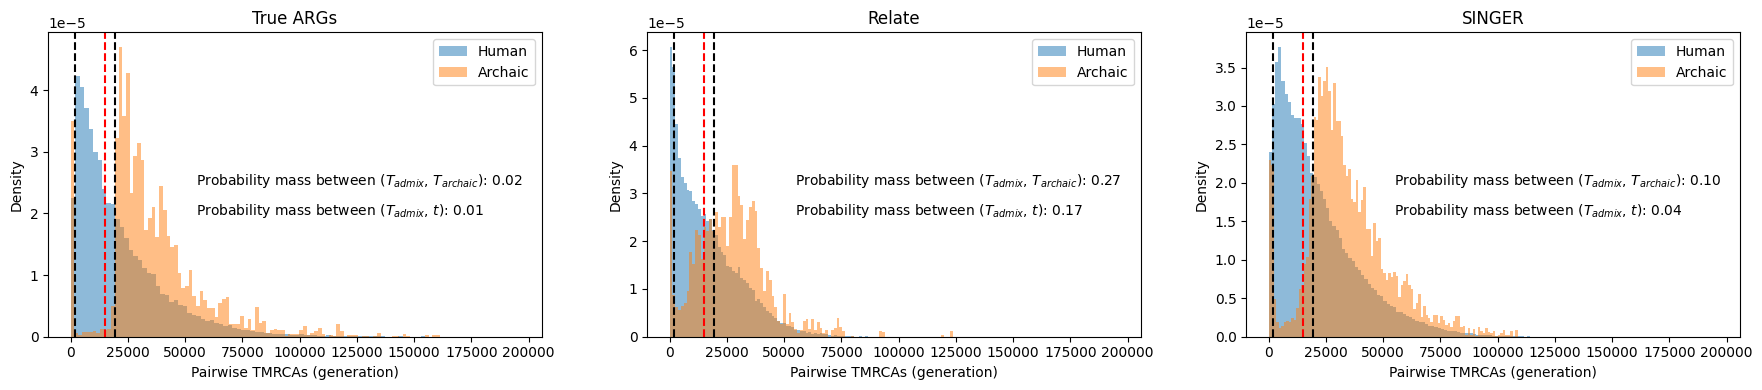

In [36]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
ax[0].hist(true_tmrca[:, :, n_idx].flatten(), bins=100, label = 'Human', alpha=0.5, density=True)
ax[0].hist(true_tmrca[:, :, didx].flatten(), bins=100, label = 'Archaic', alpha=0.5, density=True)
ax[0].set_title('True ARGs')
ax[0].set_xlabel('Pairwise TMRCAs (generation)')
ax[0].set_ylabel('Density')
ax[0].legend()
ax[0].axvline(x=1724, color='black', linestyle='--')
ax[0].axvline(x=19275, color='black', linestyle='--')
ax[0].axvline(x=15000, color='red', linestyle='--')
# probability mass between 1724 and 19275 for archaic segments
m = np.sum(true_tmrca[:, :, didx].flatten() > 1724) - np.sum(true_tmrca[:, :, didx].flatten() > 19275)
ax[0].text(0.3, 0.5, r"Probability mass between ($T_{admix}$, $T_{archaic}$):" + f" {m / len(true_tmrca[:, :, didx].flatten()):.2f}", transform=ax[0].transAxes)
m = np.sum(true_tmrca[:, :, didx].flatten() > 1724) - np.sum(true_tmrca[:, :, didx].flatten() > 15000)
ax[0].text(0.3, 0.4, r"Probability mass between ($T_{admix}$, $t$):" + f" {m / len(true_tmrca[:, :, didx].flatten()):.2f}", transform=ax[0].transAxes)
ax[1].hist(relate_tmrca[:, :, n_idx].flatten(), bins=100, label = 'Human', alpha=0.5, density=True)
ax[1].hist(relate_tmrca[:, :, didx].flatten(), bins=100, label = 'Archaic', alpha=0.5, density=True)
ax[1].set_title('Relate')
ax[1].set_xlabel('Pairwise TMRCAs (generation)')
ax[1].set_ylabel('Density')
ax[1].legend()
ax[1].axvline(x=1724, color='black', linestyle='--')
ax[1].axvline(x=19275, color='black', linestyle='--')
ax[1].axvline(x=15000, color='red', linestyle='--')
# probability mass between 1724 and 19275 for archaic segments
m = np.sum(relate_tmrca[:, :, didx].flatten() > 1724) - np.sum(relate_tmrca[:, :, didx].flatten() > 19275)
ax[1].text(0.3, 0.5, r"Probability mass between ($T_{admix}$, $T_{archaic}$):" + f" {m / len(relate_tmrca[:, :, didx].flatten()):.2f}", transform=ax[1].transAxes)
m = np.sum(relate_tmrca[:, :, didx].flatten() > 1724) - np.sum(relate_tmrca[:, :, didx].flatten() > 15000)
ax[1].text(0.3, 0.4, r"Probability mass between ($T_{admix}$, $t$):" + f" {m / len(relate_tmrca[:, :, didx].flatten()):.2f}", transform=ax[1].transAxes)
ax[2].hist(singer_tmrca[:, :, n_idx].flatten(), bins=100, label = 'Human', alpha=0.5, density=True)
ax[2].hist(singer_tmrca[:, :, didx].flatten(), bins=100, label = 'Archaic', alpha=0.5, density=True)
ax[2].set_title('SINGER')
ax[2].set_xlabel('Pairwise TMRCAs (generation)')
ax[2].set_ylabel('Density')
ax[2].legend()
ax[2].axvline(x=1724, color='black', linestyle='--')
ax[2].axvline(x=19275, color='black', linestyle='--')
ax[2].axvline(x=15000, color='red', linestyle='--')
# probability mass between 1724 and 19275 for archaic segments
m = np.sum(singer_tmrca[:, :, didx].flatten() > 1724) - np.sum(singer_tmrca[:, :, didx].flatten() > 19275)
ax[2].text(0.3, 0.5, r"Probability mass between ($T_{admix}$, $T_{archaic}$):" + f" {m / len(singer_tmrca[:, :, didx].flatten()):.2f}", transform=ax[2].transAxes)
m = np.sum(singer_tmrca[:, :, didx].flatten() > 1724) - np.sum(singer_tmrca[:, :, didx].flatten() > 15000)
ax[2].text(0.3, 0.4, r"Probability mass between ($T_{admix}$, $t$):" + f" {m / len(singer_tmrca[:, :, didx].flatten()):.2f}", transform=ax[2].transAxes)
plt.tight_layout()
plt.savefig('../images/figS3_5abc.pdf', bbox_inches='tight')

In [9]:
data = {"True ARGs": true_tmrca[:, :, didx].flatten(), "Relate": relate_tmrca[:, :, didx].flatten(), "SINGER": singer_tmrca[:, :, didx].flatten()}
df = pd.DataFrame.from_dict(data)

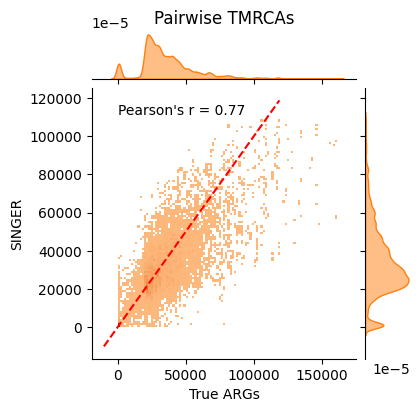

In [17]:
cls = sns.color_palette("tab10").as_hex()
g = sns.JointGrid(
    data=df,
    x="True ARGs", 
    y="SINGER",
    height=4
)
# darker blues
g.plot_joint(sns.histplot, cmap="Oranges_d", bins = 100)
g.plot_marginals(sns.kdeplot, fill=True, alpha=0.5, color=cls[1])
g.ax_marg_x.set_title('Pairwise TMRCAs')
# correlation
corr = pearsonr(df['True ARGs'], df['SINGER'])[0]
g.ax_joint.text(0.1, 0.9, f"Pearson's r = {corr:.2f}", transform=g.ax_joint.transAxes)
# g.ax_joint.set_yscale('log')
# g.ax_marg_y.set_yscale('log')
# g.ax_joint.set_xscale('log')
# g.ax_marg_x.set_xscale('log')
x_min, x_max = g.ax_joint.get_xlim()
y_min, y_max = g.ax_joint.get_ylim()
lims = [
    np.max([x_min, y_min]),
    np.min([x_max, y_max]),
]
g.ax_joint.plot(lims, lims, '--r')
plt.savefig('../images/figS3_5e.pdf', bbox_inches='tight')

# Plot "HMM performance in extreme models"

In [12]:
conf = yaml.safe_load(Path('../config/analysis.config.yaml').read_text())
seeds = conf['extreme_demo']['seeds']
pp_cutoff = conf['pp_cutoff'][1]
l_cutoff = conf['l_cutoff']
n = conf['extreme_demo']['n']

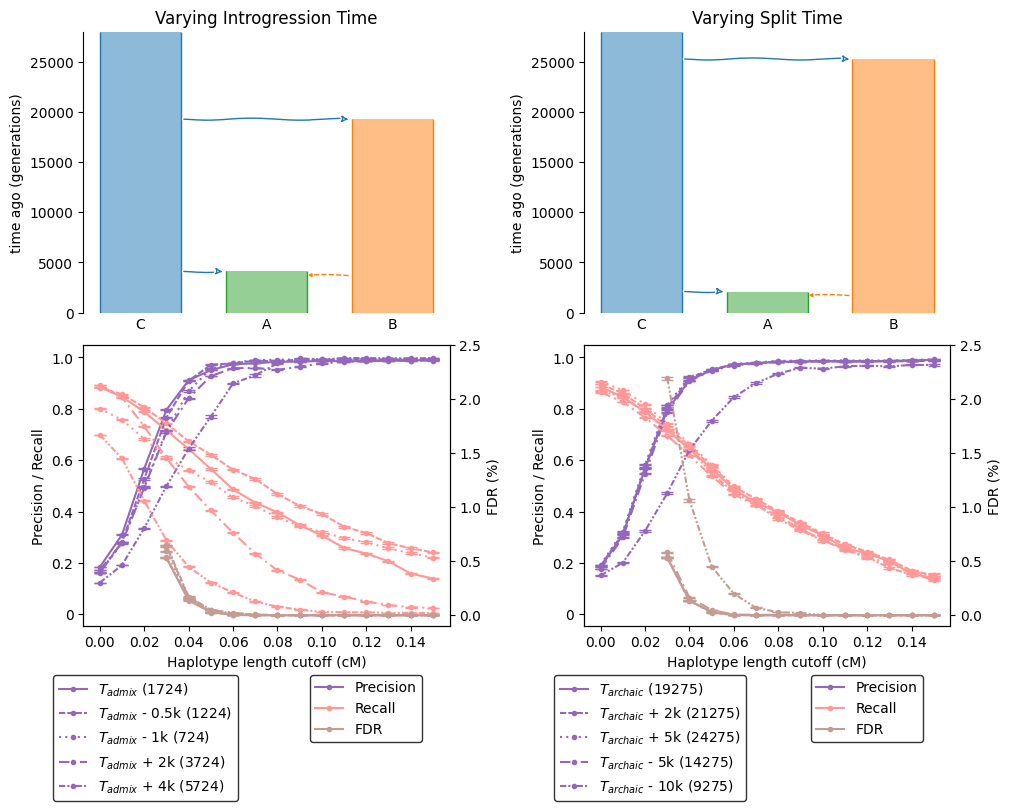

In [18]:
model = 'split_constant'
tt = conf['extreme_demo']['models'][model]['t'][0]
t1 = conf['extreme_demo']['models'][model]['t'][1]
intro = conf['extreme_demo']['models'][model]['intro'][0]
versions = conf['extreme_demo']['models'][model]['versions']
dashList = [(),(3, 1),(1, 2),(5, 2, 1, 2),(3, 1, 1, 1, 1, 1)]
colors=mcp.gen_color(cmap="tab20",n=20)
labels1=['$T_{admix}$ (1724)', '$T_{admix}$ - 0.5k (1224)', '$T_{admix}$ - 1k (724)', '$T_{admix}$ + 2k (3724)', '$T_{admix}$ + 4k (5724)']
labels2=['$T_{archaic}$ (19275)', '$T_{archaic}$ + 2k (21275)', '$T_{archaic}$ + 5k (24275)', '$T_{archaic}$ - 5k (14275)', '$T_{archaic}$ - 10k (9275)']
fig, ax = plt.subplots(2, 2, figsize=(10,8), sharey='row')
# older T_admix
ax2 = ax[1][0].twinx()
ax2.set_ylabel('FDR (%)')
ax2.set_ylim([-0.1, 2.5])
for t in range(5):
    # merge seeds
    fpath = '../results/hmm_results/extreme_demo/'+str(model)+'/' + str(versions[t]) + '/n' + str(n) + '_seed'
    t_archaic = str(intro)
    df = Figure_utils().merge_seeds(filepath=fpath, t_admix=tt, t_archaic=t_archaic, seeds=seeds)
    precision, precision_err = Figure_utils().get_datapoints(df=df, colname='precision', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
    recall, recall_err = Figure_utils().get_datapoints(df=df, colname='recall', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
    false_discovery, false_discovery_err = Figure_utils().get_datapoints(df=df, colname='false_discovery', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
    ax[1][0].errorbar(l_cutoff, precision, yerr=precision_err, fmt='--', dashes = dashList[t],marker='o',markersize=3, color=colors[8],capsize=4)
    ax[1][0].errorbar(l_cutoff, recall, yerr=recall_err, fmt='--', dashes = dashList[t],marker='o',markersize=3, color=colors[7],capsize=4)
    ax[1][0].set_ylabel('Precision / Recall')
    if t==0:
        ax[1][1].errorbar(l_cutoff, precision, yerr=precision_err, fmt='--', dashes = dashList[t],marker='o',markersize=3, color=colors[8],capsize=4)
        ax[1][1].errorbar(l_cutoff, recall, yerr=recall_err, fmt='--', dashes = dashList[t],marker='o',markersize=3, color=colors[7],capsize=4)
        ax[1][1].set_ylabel('Precision / Recall')
        rec_fdr = false_discovery
        rec_fdr_err = false_discovery_err
    ax2.errorbar(l_cutoff[3:], false_discovery[3:] *2, yerr=false_discovery_err[3:] *2, fmt='--', dashes = dashList[t],marker='o',markersize=3, color=colors[11],capsize=4)
graph=demes.load("../results/simulations/models/"+str(model)+"/"+str(model)+"_"+str(versions[3])+".yaml")
demesdraw.tubes(graph, ax=ax[0][0], title='Varying Introgression Time', max_time=28000)
ax[1][0].set_xlabel('Haplotype length cutoff (cM)')
ax[1][0].set_yticks([0.2, 0.4, 0.6, 0.8, 1], ['0.2', '0.4', '0.6', '0.8', '1.0'])
s = ax2.get_lines()
lines = ax[1][0].get_lines()
legend1 = ax[1][0].legend([lines[0], lines[3], s[0]], ['Precision','Recall','FDR'], bbox_to_anchor=(0.6, -0.15), loc='upper left')
frame1 = legend1.get_frame()
frame1.set_edgecolor('black')
legend2 = ax[1][0].legend([lines[i] for i in [0,6,12,18,24]], labels1, bbox_to_anchor=(-0.1, -0.15), loc='upper left')
frame2 = legend2.get_frame()
frame2.set_edgecolor('black')
ax[1][0].add_artist(legend1)

ax2 = ax[1][1].twinx()
ax2.set_ylabel('FDR (%)')
ax2.set_ylim([-0.1, 2.5])
ax2.errorbar(l_cutoff[3:], rec_fdr[3:] *2, rec_fdr_err[3:] *2, fmt='--', dashes = dashList[0],marker='o',markersize=3, color=colors[11],capsize=4)
for t in range(5, 9):
    # merge seeds
    fpath = '../results/hmm_results/extreme_demo/'+str(model)+'/' + str(versions[t]) + '/n' + str(n) + '_seed'
    t_archaic = str(intro)
    if t == 8:
        df = Figure_utils().merge_seeds(filepath=fpath, t_admix=t1, t_archaic=t_archaic, seeds=seeds[:3])
    else:
        df = Figure_utils().merge_seeds(filepath=fpath, t_admix=tt, t_archaic=t_archaic, seeds=seeds)
    precision, precision_err = Figure_utils().get_datapoints(df=df, colname='precision', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
    recall, recall_err = Figure_utils().get_datapoints(df=df, colname='recall', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
    false_discovery, false_discovery_err = Figure_utils().get_datapoints(df=df, colname='false_discovery', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
    ax[1][1].errorbar(l_cutoff, precision, yerr=precision_err, fmt='--', dashes = dashList[t-4],marker='o',markersize=3, color=colors[8],capsize=4)
    ax[1][1].errorbar(l_cutoff, recall, yerr=recall_err, fmt='--', dashes = dashList[t-4],marker='o',markersize=3, color=colors[7],capsize=4)
    ax[1][1].set_ylabel('Precision / Recall')
    ax2.errorbar(l_cutoff[3:], false_discovery[3:] *2, yerr=false_discovery_err[3:] *2, fmt='--', dashes = dashList[t-4],marker='o',markersize=3, color=colors[11],capsize=4)
graph=demes.load("../results/simulations/models/"+str(model)+"/"+str(model)+"_"+str(versions[6])+".yaml")
demesdraw.tubes(graph, ax=ax[0][1], title='Varying Split Time', max_time=28000)
#ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1, 1.2], ['0', '0.2', '0.4', '0.6', '0.8', '1.0', '1.2'])
ax[1][1].set_xlabel('Haplotype length cutoff (cM)')
ax[1][1].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ['0', '0.2', '0.4', '0.6', '0.8', '1.0'])
s = ax2.get_lines()
lines = ax[1][1].get_lines()
legend1 = ax[1][1].legend([lines[0], lines[3], s[0]], ['Precision','Recall','FDR'], bbox_to_anchor=(0.6, -0.15), loc='upper left')
frame1 = legend1.get_frame()
frame1.set_edgecolor('black')
legend2 = ax[1][1].legend([lines[i] for i in [0,6,12,18,24]], labels2, bbox_to_anchor=(-0.1, -0.15), loc='upper left')
frame2 = legend2.get_frame()
frame2.set_edgecolor('black')
ax[1][1].add_artist(legend1)
ax[1][1].yaxis.set_tick_params(labelleft=True)
ax[0][1].yaxis.set_tick_params(labelleft=True)
fig.set_constrained_layout(True)
ax[1][0].set_xticks([0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14], ['0.00', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14'])
ax[1][1].set_xticks([0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14], ['0.00', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14'])
plt.savefig('../images/figS2_4.pdf', bbox_inches='tight')

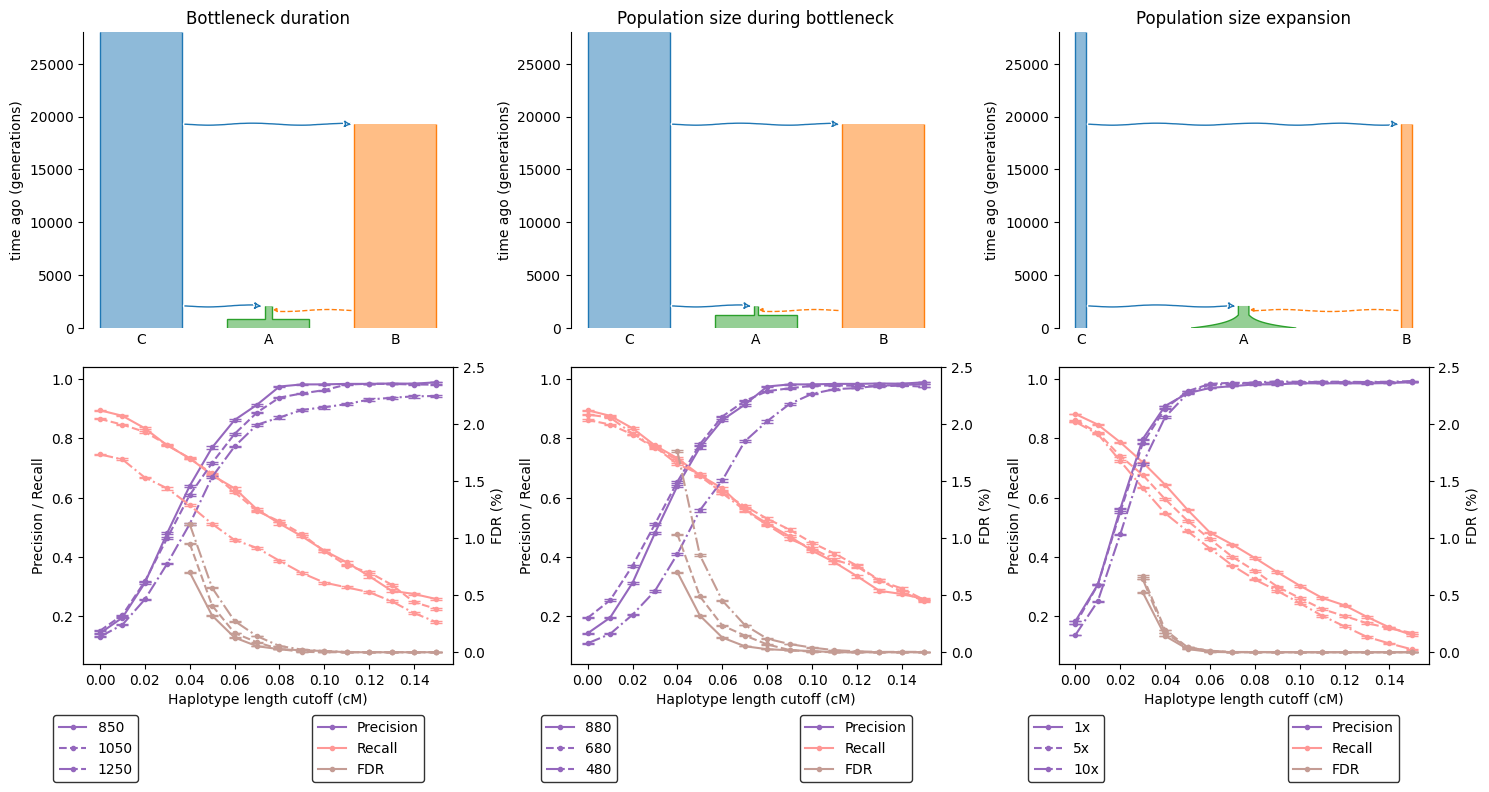

In [13]:
model = 'split_bottleneck'
tt = conf['extreme_demo']['models'][model]['t'][0]
intro = conf['extreme_demo']['models'][model]['intro'][0]
versions = conf['extreme_demo']['models'][model]['versions']
linestyles = ['-', '--', '-.', ':']
colors=mcp.gen_color(cmap="tab20",n=20)
labels1=['850', '1050', '1250']
labels2=['880', '680', '480']
fig, ax = plt.subplots(2, 3, figsize=(15,8), sharey='row')

ax2 = ax[1][0].twinx()
ax2.set_ylabel('FDR (%)')
ax2.set_ylim([-0.1, 2.5])
for t in range(3):
    # merge seeds
    fpath = '../results/hmm_results/extreme_demo/'+str(model)+'/' + str(versions[t]) + '/n' + str(n) + '_seed'
    t2 = str(intro)
    df = Figure_utils().merge_seeds(filepath=fpath, t_admix=tt, t_archaic=t2, seeds=seeds)
    precision, precision_err = Figure_utils().get_datapoints(df=df, colname='precision', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
    recall, recall_err = Figure_utils().get_datapoints(df=df, colname='recall', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
    false_discovery, false_discovery_err = Figure_utils().get_datapoints(df=df, colname='false_discovery', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
    ax[1][0].errorbar(l_cutoff, precision, yerr=precision_err, fmt=linestyles[t],marker='o',markersize=3, color=colors[8],capsize=4)
    ax[1][0].errorbar(l_cutoff, recall, yerr=recall_err, fmt=linestyles[t],marker='o',markersize=3, color=colors[7],capsize=4)
    ax[1][0].set_ylabel('Precision / Recall')
    if t==0:
        ax[1][1].errorbar(l_cutoff, precision, yerr=precision_err, fmt=linestyles[t],marker='o',markersize=3, color=colors[8],capsize=4)
        ax[1][1].errorbar(l_cutoff, recall, yerr=recall_err, fmt=linestyles[t],marker='o',markersize=3, color=colors[7],capsize=4)
        ax[1][1].set_ylabel('Precision / Recall')
        rec_fdr = false_discovery
        rec_fdr_err = false_discovery_err
    ax2.errorbar(l_cutoff[4:], false_discovery[4:] *2, yerr=false_discovery_err[4:] *2, fmt=linestyles[t],marker='o',markersize=3, color=colors[11],capsize=4)
graph=demes.load("../results/simulations/models/"+str(model)+"/"+str(model)+"_"+str(versions[2])+".yaml")
demesdraw.tubes(graph, ax=ax[0][0], title='Bottleneck duration', max_time=28000)
# older T_archaic
s = ax2.get_lines()
lines = ax[1][0].get_lines()
legend1 = ax[1][0].legend([lines[0], lines[3], s[0]], ['Precision','Recall','FDR'], bbox_to_anchor=(0.6, -0.15), loc='upper left')
frame1 = legend1.get_frame()
frame1.set_edgecolor('black')
legend2 = ax[1][0].legend([lines[i] for i in [0,6,12]], labels1, bbox_to_anchor=(-0.1, -0.15), loc='upper left')
frame2 = legend2.get_frame()
frame2.set_edgecolor('black')
ax[1][0].add_artist(legend1)

ax2 = ax[1][1].twinx()
ax2.set_ylabel('FDR (%)')
ax2.set_ylim([-0.1, 2.5])
ax2.errorbar(l_cutoff[4:], rec_fdr[4:] *2, rec_fdr_err[4:] *2, fmt=linestyles[0],marker='o',markersize=3, color=colors[11],capsize=4)
for t in range(3, 5):
    # merge seeds
    fpath = '../results/hmm_results/extreme_demo/'+str(model)+'/' + str(versions[t]) + '/n' + str(n) + '_seed'
    t2 = str(intro)
    df = Figure_utils().merge_seeds(filepath=fpath, t_admix=tt, t_archaic=t2, seeds=seeds)
    precision, precision_err = Figure_utils().get_datapoints(df=df, colname='precision', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
    recall, recall_err = Figure_utils().get_datapoints(df=df, colname='recall', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
    false_discovery, false_discovery_err = Figure_utils().get_datapoints(df=df, colname='false_discovery', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
    ax[1][1].errorbar(l_cutoff, precision, yerr=precision_err, fmt=linestyles[t-2],marker='o',markersize=3, color=colors[8],capsize=4)
    ax[1][1].errorbar(l_cutoff, recall, yerr=recall_err, fmt=linestyles[t-2],marker='o',markersize=3, color=colors[7],capsize=4)
    ax[1][1].set_ylabel('Precision / Recall')
    ax2.errorbar(l_cutoff[4:], false_discovery[4:] *2, yerr=false_discovery_err[4:] *2, fmt=linestyles[t-2],marker='o',markersize=3, color=colors[11],capsize=4)
graph=demes.load("../results/simulations/models/"+str(model)+"/"+str(model)+"_"+str(versions[4])+".yaml")
demesdraw.tubes(graph, ax=ax[0][1], title='Population size during bottleneck', max_time=28000)
#ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1, 1.2], ['0', '0.2', '0.4', '0.6', '0.8', '1.0', '1.2'])

# ax[1][0].set_xscale('log')
ax[1][0].set_xlabel('Haplotype length cutoff (cM)')
ax[1][0].set_yticks([0.2, 0.4, 0.6, 0.8, 1], ['0.2', '0.4', '0.6', '0.8', '1.0'])

# ax[1][1].set_xscale('log')
ax[1][1].set_xlabel('Haplotype length cutoff (cM)')
ax[1][1].set_yticks([0.2, 0.4, 0.6, 0.8, 1], ['0.2', '0.4', '0.6', '0.8', '1.0'])
s = ax2.get_lines()
lines = ax[1][1].get_lines()
legend1 = ax[1][1].legend([lines[0], lines[3], s[0]], ['Precision','Recall','FDR'], bbox_to_anchor=(0.6, -0.15), loc='upper left')
frame1 = legend1.get_frame()
frame1.set_edgecolor('black')
legend2 = ax[1][1].legend([lines[i] for i in [0,6,12]], labels2, bbox_to_anchor=(-0.1, -0.15), loc='upper left')
frame2 = legend2.get_frame()
frame2.set_edgecolor('black')
ax[1][1].add_artist(legend1)
ax[1][1].yaxis.set_tick_params(labelleft=True)
ax[0][1].yaxis.set_tick_params(labelleft=True)
ax[1][0].set_xticks([0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14], ['0.00', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14'])
ax[1][1].set_xticks([0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14], ['0.00', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14'])

model = 'split_growth'
tt = conf['extreme_demo']['models'][model]['t'][0]
intro = conf['extreme_demo']['models'][model]['intro'][0]
versions = conf['extreme_demo']['models'][model]['versions']
linestyles = ['-', '--', '-.', ':']
colors=mcp.gen_color(cmap="tab20",n=20)
labels=['1x', '5x','10x']
# older T_admix
ax2 = ax[1][2].twinx()
ax2.set_ylabel('FDR (%)')
ax2.set_ylim([-0.1, 2.5])
fpath = '../results/hmm_results/extreme_demo/split_constant/m2_ori/n' + str(n) + '_seed'
t2 = str(intro)
df = Figure_utils().merge_seeds(filepath=fpath, t_admix=tt, t_archaic=t2, seeds=seeds)
precision, precision_err = Figure_utils().get_datapoints(df=df, colname='precision', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
recall, recall_err = Figure_utils().get_datapoints(df=df, colname='recall', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
false_discovery, false_discovery_err = Figure_utils().get_datapoints(df=df, colname='false_discovery', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
ax[1][2].errorbar(l_cutoff, precision, yerr=precision_err, fmt=linestyles[0],marker='o',markersize=3, color=colors[8],capsize=4)
ax[1][2].errorbar(l_cutoff, recall, yerr=recall_err, fmt=linestyles[0],marker='o',markersize=3, color=colors[7],capsize=4)
ax[1][2].set_ylabel('Precision / Recall')
ax2.errorbar(l_cutoff[3:], false_discovery[3:] *2, yerr=false_discovery_err[3:] *2, fmt=linestyles[0],marker='o',markersize=3, color=colors[11],capsize=4)
for t in range(len(versions)):
    # merge seeds
    fpath = '../results/hmm_results/extreme_demo/'+str(model)+'/' + str(versions[t]) + '/n' + str(n) + '_seed'
    t2 = str(intro)
    df = Figure_utils().merge_seeds(filepath=fpath, t_admix=tt, t_archaic=t2, seeds=seeds)
    precision, precision_err = Figure_utils().get_datapoints(df=df, colname='precision', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
    recall, recall_err = Figure_utils().get_datapoints(df=df, colname='recall', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
    false_discovery, false_discovery_err = Figure_utils().get_datapoints(df=df, colname='false_discovery', ntime=30, pp_cutoff=pp_cutoff, l_cutoff=l_cutoff)
    ax[1][2].errorbar(l_cutoff, precision, yerr=precision_err, fmt=linestyles[t+1],marker='o',markersize=3, color=colors[8],capsize=4)
    ax[1][2].errorbar(l_cutoff, recall, yerr=recall_err, fmt=linestyles[t+1],marker='o',markersize=3, color=colors[7],capsize=4)
    ax[1][2].set_ylabel('Precision / Recall')
    ax2.errorbar(l_cutoff[3:], false_discovery[3:] *2, yerr=false_discovery_err[3:] *2, fmt=linestyles[t+1],marker='o',markersize=3, color=colors[11],capsize=4)
graph=demes.load("../results/simulations/models/"+str(model)+"/"+str(model)+"_"+str(versions[1])+".yaml")
demesdraw.tubes(graph, ax=ax[0][2], title='Population size expansion', max_time=28000)
s = ax2.get_lines()
lines = ax[1][2].get_lines()
legend1 = ax[1][2].legend([lines[0], lines[3], s[0]], ['Precision','Recall','FDR'], bbox_to_anchor=(0.6, -0.15), loc='upper left')
frame1 = legend1.get_frame()
frame1.set_edgecolor('black')
legend2 = ax[1][2].legend([lines[i] for i in [0,6,12]], labels, bbox_to_anchor=(-0.1, -0.15), loc='upper left')
frame2 = legend2.get_frame()
frame2.set_edgecolor('black')
ax[1][2].add_artist(legend1)
ax[1][2].set_xlabel('Haplotype length cutoff (cM)')
ax[1][2].set_xticks([0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14], ['0.00', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14'])
ax[1][2].yaxis.set_tick_params(labelleft=True)
ax[0][2].yaxis.set_tick_params(labelleft=True)

fig.tight_layout()
plt.savefig('../images/figS2_5.pdf', bbox_inches='tight')

In [218]:
truth = Performance_utils().read_truth_bed("../results/simulations/outputs/ooa_neanderthal5r19_simp/m2_ori/n100_seed5.merged.bed", 200)
truth

array([[4.686112, 4.739996],
       [5.226212, 5.232835],
       [5.662616, 5.69504 ],
       ...,
       [5.390349, 5.621897],
       [8.239587, 8.272299],
       [9.347743, 9.632059]])

In [221]:
df = pd.read_csv('../results/hmm_results/inference_comparison/ooa_neanderthal5r19_simp/m2_ori/hmmix/n100_seed3.tsk_0.decoded.diploid.txt', sep='\s+')
df['length'] =  df['length'] / 1e6
df.head()

,chrom,start,end,length,state,mean_prob,snps
0,1,0,580000,0.581,Human,0.99377,33
1,1,581000,623000,0.043,Archaic,0.58319,11
2,1,624000,3746000,3.123,Human,0.98729,215
3,1,3747000,3794000,0.048,Archaic,0.89131,15
4,1,3795000,4945000,1.151,Human,0.98997,51


<Axes: ylabel='time ago (generations)'>

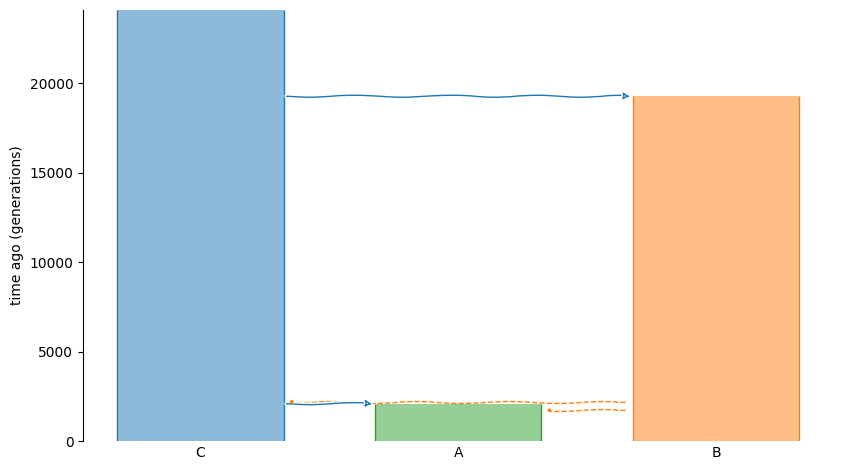

In [4]:
ts = tszip.decompress("../results/simulations/outputs/ooa_neanderthal5r19_simp/m2_ori/n100_seed3.tsz")

(array([137.,  66.,  85.,  52.,  30.,  51.,  59.,  38.,  12.,   5.]),
 array([   16. ,  1525.6,  3035.2,  4544.8,  6054.4,  7564. ,  9073.6,
        10583.2, 12092.8, 13602.4, 15112. ]),
 <BarContainer object of 10 artists>)

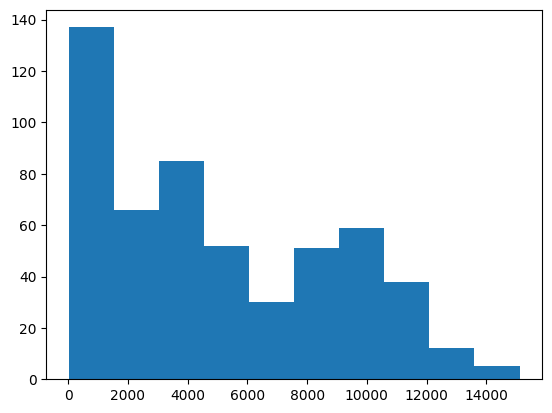

In [65]:
demo = msprime.Demography.from_demes(demes.load("../results/simulations/models/ooa_neanderthal5r19_simp/ooa_neanderthal5r19_simp_m2_ori.yaml"))
pop_dict = {i.name: i.id for i in demo.populations}
arg_utils = ARG_utils(
    afr_poplabel=pop_dict['A'],
    ghost_poplabel=pop_dict['B']
)
arg_utils.add_tree_sequence(ts)
treespan = arg_utils.treespan
ils=[]
for i in range(200):
    _, _, _, upper_null = arg_utils.extract_branch_boundaries(i, 1724)
    t = 0
    ind_out = []
    while t < len(upper_null):
        if upper_null[t] >= 19275:
            j = t
            temp_pos = []
            temp_pp = []
            while j < len(upper_null) and upper_null[j] >= 19275:
                temp_pos.append(j)
                temp_pp.append(upper_null[j])
                j += 1
            ind_out.append(
                treespan[np.max(temp_pos)][1] - treespan[np.min(temp_pos)][0]
            )
            t = j
        else:
            t += 1
    ils = ils + ind_out
plt.hist(ils)

Text(0.5, 0, '[1383.0,1121.9]')

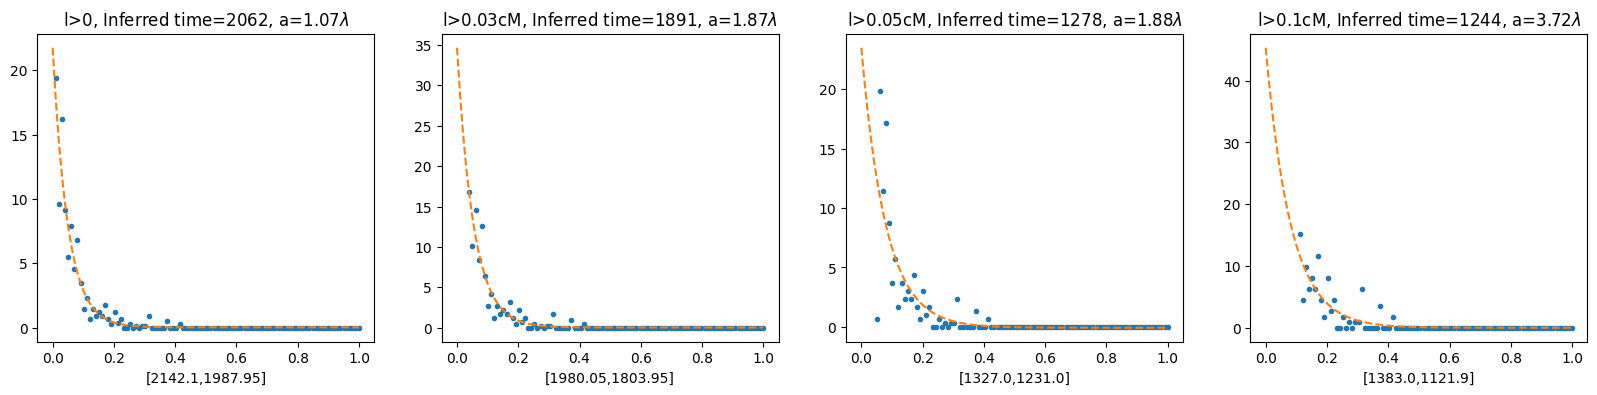

In [216]:
from scipy.optimize import curve_fit
fig, ax = plt.subplots(1, 4, figsize=(20,4))
def monoExp(x, a, b, c):
    return a * b * np.exp(-b * x) + c
def getTime(x):
    return int(x / (0.98*1e-2))
def midbin(bins):
    out=[]
    for i in range(1, len(bins)):
        out.append(bins[0] + i*(bins[1]-bins[0]))
    return np.array(out)
def boot(x, ntimes, samplesize):
    out=[]
    for i in range(ntimes):
        sample=np.random.choice(x, int(len(x)*samplesize), replace=False)
        ys, xs = np.histogram(sample, np.linspace(0, 1, 100))
        j = 0
        while ys[j]==0:
            j+=1
        params, cv = curve_fit(monoExp, midbin(xs[j:]), ys[j:]/(sum(ys)*xs[1]), p0)
        out.append(getTime(params[1]))
    return np.mean(out), np.percentile(out, 95), np.percentile(out, 5)
        
truth = np.array(truth)
p0 = (2, .01, 0) # start with values near those we expect
ys, xs = np.histogram(truth, np.linspace(0, 1, 100))
j=0
while ys[j]==0:
    j+=1
params, cv = curve_fit(monoExp, midbin(xs[j:]), ys[j:]/(sum(ys)*xs[1]), p0)
a, b, c = params
ax[0].plot(midbin(xs[j:]), ys[j:]/(sum(ys)*xs[1]), '.', label="data")
ax[0].plot(xs, monoExp(xs, a, b, c), '--', label="fitted")
ax[0].set_title("l>0, Inferred time=" + str(getTime(params[1])) + ", a=" + str(round(a, 2))+"$\lambda$")
m, l, h = boot(truth, 1000, 0.9)
ax[0].set_xlabel("["+str(round(l, 2))+"," + str(round(h, 2))+ "]")

p0 = (2, .01, 0) # start with values near those we expect
ys, xs = np.histogram(truth[truth>0.03], np.linspace(0, 1, 100))
j=0
while ys[j]==0:
    j+=1
params, cv = curve_fit(monoExp, midbin(xs[j:]), ys[j:]/(sum(ys)*xs[1]), p0)
a, b, c = params
ax[1].plot(midbin(xs[j:]), ys[j:]/(sum(ys)*xs[1]), '.', label="data")
ax[1].plot(xs, monoExp(xs, a, b, c), '--', label="fitted")
ax[1].set_title("l>0.03cM, Inferred time="+ str(int(params[1] / (0.98*1e-2)))+ ", a=" + str(round(a, 2))+"$\lambda$")
m, l, h = boot(truth[truth>0.03], 1000, 0.9)
ax[1].set_xlabel("["+str(round(l, 2))+"," + str(round(h, 2))+ "]")

p0 = (2, .01, 0) # start with values near those we expect
ys, xs = np.histogram(truth[truth>0.05], np.linspace(0, 1, 100))
j=0
while ys[j]==0:
    j+=1
params, cv = curve_fit(monoExp, midbin(xs[j:]), ys[j:]/(sum(ys)*xs[1]), p0)
a, b, c = params
ax[2].plot(midbin(xs[j:]), ys[j:]/(sum(ys)*xs[1]), '.', label="data")
ax[2].plot(xs, monoExp(xs, a, b, c), '--', label="fitted")
ax[2].set_title("l>0.05cM, Inferred time="+ str(int(params[1] / (0.98*1e-2)))+ ", a=" + str(round(a, 2))+"$\lambda$")
m, l, h = boot(truth[truth>0.05], 1000, 0.9)
ax[2].set_xlabel("["+str(round(l, 2))+"," + str(round(h, 2))+ "]")

p0 = (2, .01, 0) # start with values near those we expect
ys, xs = np.histogram(truth[truth>0.1], np.linspace(0, 1, 100))
j=0
while ys[j]==0:
    j+=1
params, cv = curve_fit(monoExp, midbin(xs[j:]), ys[j:]/(sum(ys)*xs[1]), p0)
a, b, c = params
ax[3].plot(midbin(xs[j:]), ys[j:]/(sum(ys)*xs[1]), '.', label="data")
ax[3].plot(xs, monoExp(xs, a, b, c), '--', label="fitted")
ax[3].set_title("l>0.1cM, Inferred time="+ str(int(params[1] / (0.98*1e-2)))+ ", a=" + str(round(a, 2))+"$\lambda$")
m, l, h = boot(truth[truth>0.1], 1000, 0.9)
ax[3].set_xlabel("["+str(round(l, 2))+"," + str(round(h, 2))+ "]")

In [4]:
from workflow.scripts.ARGweaver_utils import ARGweaver_to_ts
argweaver_to_ts = ARGweaver_to_ts()
filename = "/Users/zhangyulin/Desktop/site0_10M.1790.smc"
ts, ts_sample_names = argweaver_to_ts.read_smc(filename)
ts_sample_names

{0: 'msp_34',
 1: 'msp_9',
 2: 'msp_10',
 3: 'msp_37',
 4: 'msp_5',
 5: 'msp_4',
 6: 'msp_2',
 7: 'msp_6',
 8: 'msp_31',
 9: 'msp_20',
 10: 'msp_26',
 11: 'msp_38',
 12: 'msp_25',
 13: 'msp_8',
 14: 'msp_17',
 15: 'msp_21',
 16: 'msp_15',
 17: 'msp_22',
 18: 'msp_27',
 19: 'msp_12',
 20: 'msp_0',
 21: 'msp_3',
 22: 'msp_7',
 23: 'msp_1',
 24: 'msp_11',
 25: 'msp_39',
 26: 'msp_29',
 27: 'msp_35',
 28: 'msp_32',
 29: 'msp_36',
 30: 'msp_23',
 31: 'msp_14',
 32: 'msp_18',
 33: 'msp_28',
 34: 'msp_19',
 35: 'msp_24',
 36: 'msp_16',
 37: 'msp_30',
 38: 'msp_13',
 39: 'msp_33'}

In [6]:
vcf="../results/simulations/outputs/ooa_neanderthal5r19_simp/m2_ori/n10_seed3.vcf"
from workflow.scripts.ARGweaver_utils import ARGweaver_related_utils
argweaver_utils=ARGweaver_related_utils()
argweaver_utils.getSitesInput(input_size=1e7, vcffile_path=vcf, outpref="../test")